## AgriBrain: AI-Powered Agricultural Market Intelligence System.

AgriBrain is an end-to-end agritech recommendation engine that leverages real-time soil, weather, and market data to optimize crop selection for Kenyan farmers. The platform actively combats the agricultural "Cobweb Phenomenon"- a cycle of market oversupply and price crashes caused by farmer reliance in past planted crops and historical prices as their main source of choice. By utilizing predictive machibe learning and an LLM-driven market analysis agent, AgriBrain breaks this cycle by recommending high-demand, ecologically viable viable alternative crops that maximize harvest profitability.





## Key Stakeholders
1. Farmers(Primary users)
- Need guidance on **what to grow** and **when to grow**

- This will help them **avoid overproduction** and **maximize profits**

2. Government and Policy Makers
- Use insights for **food security planning** and **import and export decision** and also **issue early warnings for shortages**


## Business Problem
The current project will help solve the current challenges that the farmers are facing such as **relying in guesswork** and **use of past experience** which often leads to oversupply and price crashes and shortages which leads to food insecurity. **This predictve intelligence will combine different data and use machine learning to guide farmers in their agricultural decisions**

## Data Source.

- Datasets used are from FAOSTAT. They include data on **exchange rate, yield, commodity balance food, commodity price index, macro indicators, producer prices, fertliser, and pesticide.** All FAOSTAT datasets are yearly.

- Data from Kenya Agricultural Market Information System, a government platform designed to track and share agricultural market information across Kenya. Kamis is widely used in **price modelling, food security analysis, and agricultural research.** Kamis collects real-time data across the country. It includes this like **Commodity information, price data(wholesale, retail price), market details(market name, market type), time features(daily), unit of measure(per kg, per bag, per crate)**.

- This data is especially important in our price modelling since its a time-series data that easily works with models such as ARIMA, SARIMA and Prophet.

# Dataset 1: Yield

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from prophet import Prophet
import warnings
warnings.filterwarnings("ignore")
from tqdm.autonotebook import tqdm
warnings.filterwarnings("ignore",category=UserWarning)
warnings.filterwarnings("ignore",category=FutureWarning)

import logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)



In [2]:
yield_df = pd.read_csv('csvfiles/yield.csv.csv')
yield_df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,404,Kenya,5412,Yield,1929.07,"Abaca, manila hemp, raw",1991,1991,kg/ha,1139.6,E,Estimated value,NaN
1,QCL,Crops and livestock products,404,Kenya,5412,Yield,1929.07,"Abaca, manila hemp, raw",1992,1992,kg/ha,1125.0,E,Estimated value,NaN
2,QCL,Crops and livestock products,404,Kenya,5412,Yield,1929.07,"Abaca, manila hemp, raw",1993,1993,kg/ha,1154.3,E,Estimated value,NaN
3,QCL,Crops and livestock products,404,Kenya,5412,Yield,1929.07,"Abaca, manila hemp, raw",1994,1994,kg/ha,1139.7,E,Estimated value,NaN
4,QCL,Crops and livestock products,404,Kenya,5412,Yield,1929.07,"Abaca, manila hemp, raw",1995,1995,kg/ha,1126.1,E,Estimated value,NaN


In [3]:
print(yield_df.shape)
print("\nColumns:")
print(yield_df.columns.tolist())

(4396, 15)

Columns:
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']


## Renaming columns to lowercase

In [4]:
yield_df = yield_df.rename(columns={
    "Area": "area",
    "Item": "item",
    "Year" : "year",
    "Unit" :"unit",
    "Value": "yield_kg_per_ha"
    
})

## Fixing the year datatype

In [5]:
yield_df['year'] = yield_df['year'].astype(int)

## Checking for duplicates

In [6]:
print( "Total number of duplicate rows:", yield_df.duplicated().sum())

Total number of duplicate rows: 0


In [7]:
# Final clean dataset
yield_clean = yield_df[['item','year','unit','yield_kg_per_ha']].copy()

In [8]:
print(yield_clean.shape)
print(yield_clean.head())

(4396, 4)
                      item  year   unit  yield_kg_per_ha
0  Abaca, manila hemp, raw  1991  kg/ha           1139.6
1  Abaca, manila hemp, raw  1992  kg/ha           1125.0
2  Abaca, manila hemp, raw  1993  kg/ha           1154.3
3  Abaca, manila hemp, raw  1994  kg/ha           1139.7
4  Abaca, manila hemp, raw  1995  kg/ha           1126.1


## Exploratory Data Analysis

In [9]:
print(yield_clean.info())
print("\nSummary Statistics:")
print(yield_clean.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4396 entries, 0 to 4395
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item             4396 non-null   object 
 1   year             4396 non-null   int64  
 2   unit             4396 non-null   object 
 3   yield_kg_per_ha  4396 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 137.5+ KB
None

Summary Statistics:
              year  yield_kg_per_ha
count  4396.000000      4396.000000
mean   1996.414468      7076.352116
std      17.810920     11569.827178
min    1961.000000        33.300000
25%    1982.000000       833.300000
50%    1998.000000      4000.000000
75%    2011.000000      9760.350000
max    2024.000000    121184.500000


## Top Crops by average yield

In [10]:
top_crops = (yield_clean.groupby('item')['yield_kg_per_ha']
             .mean()
             .sort_values(ascending=False)
             .head(15))

print("\nTop 15 Crops by Average Yield (kg/ha):")
print(top_crops)


Top 15 Crops by Average Yield (kg/ha):
item
Sugar cane                       76965.676562
Pineapples                       39807.071875
Cabbages                         24246.673529
Carrots and turnips              19456.739394
Watermelons                      17306.766667
Tomatoes                         16656.681250
Bananas                          14548.820312
Avocados                         14324.610937
Spinach                          14237.400000
Cauliflowers and broccoli        14188.621212
Plantains and cooking bananas    13356.946875
Green garlic                     13250.003125
Lettuce and chicory              12049.385294
Papayas                          11373.837500
Cucumbers and gherkins           10137.300000
Name: yield_kg_per_ha, dtype: float64


## VISUALIZATION

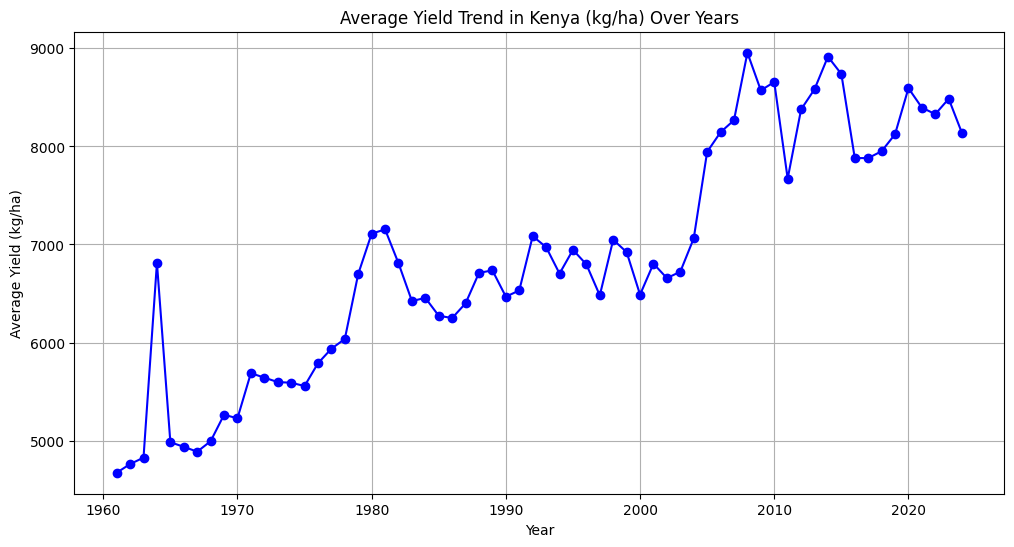

In [11]:
plt.figure(figsize=(12,6))
yield_clean.groupby('year')['yield_kg_per_ha'].mean().plot(kind='line',marker='o',color='blue')
plt.title('Average Yield Trend in Kenya (kg/ha) Over Years')
plt.xlabel('Year')
plt.ylabel('Average Yield (kg/ha)')
plt.grid(True)
plt.show()

# Dataset 2: Food Balance (Food)

In [12]:
import pandas as pd

fdbalance_df = pd.read_csv("csvfiles/FAOSTAT_data_commodity balances_food.csv")
print(fdbalance_df.head())

  Domain Code                 Domain  Area Code (M49)   Area  Element Code  \
0         FBS  Food Balances (2010-)              404  Kenya           511   
1         FBS  Food Balances (2010-)              404  Kenya           511   
2         FBS  Food Balances (2010-)              404  Kenya           511   
3         FBS  Food Balances (2010-)              404  Kenya           511   
4         FBS  Food Balances (2010-)              404  Kenya           511   

                         Element Item Code (FBS)        Item  Year Code  Year  \
0  Total Population - Both sexes           S2501  Population       2010  2010   
1  Total Population - Both sexes           S2501  Population       2011  2011   
2  Total Population - Both sexes           S2501  Population       2012  2012   
3  Total Population - Both sexes           S2501  Population       2013  2013   
4  Total Population - Both sexes           S2501  Population       2014  2014   

      Unit     Value Flag                   

#### From this dataset the strongest feature is:
#### National_Stock_Deficit_Ratio
##### * (Consumption - Production) / Production

In [13]:
fdbalance_df.columns


Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (FBS)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')

In [14]:
fdbalance_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20167 entries, 0 to 20166
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       20167 non-null  object 
 1   Domain            20167 non-null  object 
 2   Area Code (M49)   20167 non-null  int64  
 3   Area              20167 non-null  object 
 4   Element Code      20167 non-null  int64  
 5   Element           20167 non-null  object 
 6   Item Code (FBS)   20167 non-null  object 
 7   Item              20167 non-null  object 
 8   Year Code         20167 non-null  int64  
 9   Year              20167 non-null  int64  
 10  Unit              20167 non-null  object 
 11  Value             20167 non-null  float64
 12  Flag              20167 non-null  object 
 13  Flag Description  20167 non-null  object 
 14  Note              0 non-null      float64
dtypes: float64(2), int64(4), object(9)
memory usage: 2.3+ MB


In [15]:
fdbalance_df['Element'].unique()

array(['Total Population - Both sexes', 'Production', 'Import quantity',
       'Stock Variation', 'Export quantity', 'Domestic supply quantity',
       'Feed', 'Seed', 'Losses', 'Processing', 'Other uses (non-food)',
       'Tourist consumption', 'Residuals', 'Food',
       'Food supply quantity (kg/capita/yr)',
       'Food supply (kcal/capita/day)', 'Food supply (kcal)',
       'Protein supply quantity (g/capita/day)',
       'Protein supply quantity (t)',
       'Fat supply quantity (g/capita/day)', 'Fat supply quantity (t)'],
      dtype=object)

In [16]:
fdbalance_df['Item'].unique()

array(['Population', 'Wheat and products', 'Rice and products',
       'Barley and products', 'Maize and products', 'Rye and products',
       'Oats', 'Millet and products', 'Sorghum and products',
       'Cereals, other', 'Cassava and products', 'Potatoes and products',
       'Sweet potatoes', 'Yams', 'Roots, Other', 'Sugar cane',
       'Sugar beet', 'Sugar non-centrifugal', 'Sugar (Raw Equivalent)',
       'Sweeteners, Other', 'Honey', 'Beans', 'Peas',
       'Pulses, Other and products', 'Nuts and products', 'Soyabeans',
       'Groundnuts', 'Sunflower seed', 'Rape and Mustardseed',
       'Cottonseed', 'Coconuts - Incl Copra', 'Sesame seed',
       'Palm kernels', 'Olives (including preserved)', 'Oilcrops, Other',
       'Soyabean Oil', 'Groundnut Oil', 'Sunflowerseed Oil',
       'Rape and Mustard Oil', 'Cottonseed Oil', 'Palmkernel Oil',
       'Palm Oil', 'Coconut Oil', 'Sesameseed Oil', 'Olive Oil',
       'Ricebran Oil', 'Maize Germ Oil', 'Oilcrops Oil, Other',
       'Tomat

## Transform the dataset

In [17]:
print("shape:", fdbalance_df.shape)
print("\ncolumns:")
print(fdbalance_df.columns.tolist())

print("\nunique units:")
print(fdbalance_df["Unit"].value_counts(dropna=False))

print("\nunique elements:")
print(fdbalance_df["Element"].value_counts(dropna=False))

shape: (20167, 15)

columns:
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (FBS)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']

unique units:
Unit
1000 t          11548
g/cap/d          2448
t                2448
kg/cap           1261
million Kcal     1224
kcal/cap/d       1224
1000 No            14
Name: count, dtype: int64

unique elements:
Element
Domestic supply quantity                  1343
Export quantity                           1272
Food                                      1261
Food supply quantity (kg/capita/yr)       1261
Import quantity                           1257
Fat supply quantity (t)                   1224
Food supply (kcal/capita/day)             1224
Protein supply quantity (t)               1224
Fat supply quantity (g/capita/day)        1224
Food supply (kcal)                        1224
Protein supply quantity (g/capita/day)    1224
Residuals                                 1189


In [18]:
elements_to_keep = [
    "Production",
    "Import quantity",
    "Export quantity",
    "Domestic supply quantity",
    "Food",
    "Feed",
    "Seed",
    "Processing",
    "Losses",
    "Stock Variation",
    "Other uses (non-food)"
]

In [19]:
# Filter by unit
fdbalance_clean = fdbalance_df[fdbalance_df["Unit"] == "1000 t"]

# Filter by elements
elements_to_keep = [
    "Production",
    "Import quantity",
    "Export quantity",
    "Domestic supply quantity",
    "Food",
    "Feed",
    "Seed",
    "Processing",
    "Losses",
    "Stock Variation",
    "Other uses (non-food)"
]

fdbalance_clean = fdbalance_clean[
    fdbalance_clean["Element"].isin(elements_to_keep)
]

print("new shape:", fdbalance_clean.shape)
print("\nremaining elements:")
print(fdbalance_clean["Element"].value_counts())

new shape: (9289, 15)

remaining elements:
Element
Domestic supply quantity    1343
Export quantity             1272
Food                        1261
Import quantity             1257
Stock Variation             1147
Production                  1112
Losses                       667
Processing                   393
Feed                         349
Seed                         263
Other uses (non-food)        225
Name: count, dtype: int64


## Pivoting
Converting the units under elements ccolumn from long format (Element as rows) to wide format (Element as columns)

In [20]:
fdbalance_pivot = fdbalance_clean.pivot_table(
    index=["Area", "Item", "Year"],
    columns="Element",
    values="Value",
    aggfunc="sum"
).reset_index()

# remove column name grouping
fdbalance_pivot.columns.name = None

print("shape:", fdbalance_pivot.shape)
print("\ncolumns:")
print(fdbalance_pivot.columns.tolist())

shape: (1343, 14)

columns:
['Area', 'Item', 'Year', 'Domestic supply quantity', 'Export quantity', 'Feed', 'Food', 'Import quantity', 'Losses', 'Other uses (non-food)', 'Processing', 'Production', 'Seed', 'Stock Variation']


#### Now  the columns are:
* Area
* Item
* Year
* Production
* Import quantity
* Export quantity
* Food
* Feed
* Processing
* Losses etc.

Each row = one crop in one year

## Final cleaning

In [21]:
fdbalance_final = fdbalance_pivot.copy()

fdbalance_final.columns = [
    col.lower().replace(" ", "_").replace("(", "").replace(")", "")
    for col in fdbalance_final.columns
]

print(fdbalance_final.columns.tolist())

['area', 'item', 'year', 'domestic_supply_quantity', 'export_quantity', 'feed', 'food', 'import_quantity', 'losses', 'other_uses_non-food', 'processing', 'production', 'seed', 'stock_variation']


## Creating the core features

In [22]:
# Supply
fdbalance_final["supply"] = (
    fdbalance_final["production"].fillna(0) +
    fdbalance_final["import_quantity"].fillna(0)
)

# Demand
fdbalance_final["demand"] = (
    fdbalance_final["food"].fillna(0) +
    fdbalance_final["feed"].fillna(0) +
    fdbalance_final["processing"].fillna(0) +
    fdbalance_final["export_quantity"].fillna(0) +
    fdbalance_final["losses"].fillna(0) +
    fdbalance_final["other_uses_non-food"].fillna(0)
)

# Market balance (VERY IMPORTANT)
fdbalance_final["balance"] = fdbalance_final["supply"] - fdbalance_final["demand"]

print(fdbalance_final[["item", "year", "supply", "demand", "balance"]].head())

                item  year  supply  demand  balance
0  Alcohol, Non-Food  2010    18.0    19.0     -1.0
1  Alcohol, Non-Food  2011    22.0    21.0      1.0
2  Alcohol, Non-Food  2012    22.0    21.0      1.0
3  Alcohol, Non-Food  2013    17.0    17.0      0.0
4  Alcohol, Non-Food  2014    36.0    28.0      8.0


What this does:
* supply → how much exists
* demand → how much is used
* balance → positive (oversupply =price drop risk) and negative (shortage = opportunity crop)

## Final cleaning

In [23]:
# make one final clean copy
fdbalance_final = fdbalance_pivot.copy()

# cleaner column names
fdbalance_final.columns = [
    col.lower()
       .replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
       .replace("-", "_")
    for col in fdbalance_final.columns
]

# create core features
fdbalance_final["supply"] = (
    fdbalance_final["production"].fillna(0) +
    fdbalance_final["import_quantity"].fillna(0)
)

fdbalance_final["demand"] = (
    fdbalance_final["food"].fillna(0) +
    fdbalance_final["feed"].fillna(0) +
    fdbalance_final["processing"].fillna(0) +
    fdbalance_final["export_quantity"].fillna(0) +
    fdbalance_final["losses"].fillna(0) +
    fdbalance_final["other_uses_non_food"].fillna(0)
)

fdbalance_final["balance"] = fdbalance_final["supply"] - fdbalance_final["demand"]

fdbalance_final["market_signal"] = fdbalance_final["balance"].apply(
    lambda x: "oversupply" if x > 0 else ("shortage" if x < 0 else "balanced")
)

# preview
print(fdbalance_final[["item", "year", "supply", "demand", "balance", "market_signal"]].head())

# remove clearly irrelevant items
exclude_keywords = [
    "alcohol",
    "beverages",
    "stimulants",
    "miscellaneous",
    "non-food"
]

fdbalance_final = fdbalance_final[
    ~fdbalance_final["item"].str.lower().str.contains("|".join(exclude_keywords))
]

print("new shape after filtering:", fdbalance_final.shape)

# save
fdbalance_final.to_csv("fdbalance_final.csv", index=False)

print("\nSaved as: fdbalance_final.csv")
print("Final shape:", fdbalance_final.shape)

                item  year  supply  demand  balance market_signal
0  Alcohol, Non-Food  2010    18.0    19.0     -1.0      shortage
1  Alcohol, Non-Food  2011    22.0    21.0      1.0    oversupply
2  Alcohol, Non-Food  2012    22.0    21.0      1.0    oversupply
3  Alcohol, Non-Food  2013    17.0    17.0      0.0      balanced
4  Alcohol, Non-Food  2014    36.0    28.0      8.0    oversupply
new shape after filtering: (1287, 18)

Saved as: fdbalance_final.csv
Final shape: (1287, 18)


In [24]:
print(fdbalance_final.columns.tolist())
print(fdbalance_final.head())

['area', 'item', 'year', 'domestic_supply_quantity', 'export_quantity', 'feed', 'food', 'import_quantity', 'losses', 'other_uses_non_food', 'processing', 'production', 'seed', 'stock_variation', 'supply', 'demand', 'balance', 'market_signal']
     area                 item  year  domestic_supply_quantity  \
14  Kenya  Apples and products  2010                       9.0   
15  Kenya  Apples and products  2011                      10.0   
16  Kenya  Apples and products  2012                      10.0   
17  Kenya  Apples and products  2013                       9.0   
18  Kenya  Apples and products  2014                      11.0   

    export_quantity  feed  food  import_quantity  losses  other_uses_non_food  \
14              3.0   NaN   9.0              9.0     0.0                  NaN   
15              1.0   NaN  10.0             10.0     0.0                  NaN   
16              0.0   NaN  10.0              8.0     0.0                  NaN   
17              3.0   NaN  10.0     

In [25]:
print(fdbalance_final["item"].unique()[:20])

['Apples and products' 'Aquatic Animals, Others' 'Aquatic Plants'
 'Bananas' 'Barley and products' 'Beans' 'Beer' 'Bovine Meat'
 'Butter, Ghee' 'Cassava and products' 'Cephalopods' 'Cereals, other'
 'Citrus, Other' 'Cloves' 'Cocoa Beans and products' 'Coconut Oil'
 'Coconuts - Incl Copra' 'Coffee and products' 'Cottonseed'
 'Cottonseed Oil']


## Save

In [26]:
# save
fdbalance_final.to_csv("fdbalance_final.csv", index=False)

# Dataset 3 ---Producer prices

In [28]:
import pandas as pd

ppi_df = pd.read_csv("csvfiles\FAOSTAT_data_producer prices.csv")
print(ppi_df.head())

  Domain Code           Domain  Area Code (M49)   Area  Element Code  \
0          PP  Producer Prices              404  Kenya          5539   
1          PP  Producer Prices              404  Kenya          5539   
2          PP  Producer Prices              404  Kenya          5539   
3          PP  Producer Prices              404  Kenya          5539   
4          PP  Producer Prices              404  Kenya          5539   

                                  Element Item Code (CPC)  \
0  Producer Price Index (2014-2016 = 100)           01654   
1  Producer Price Index (2014-2016 = 100)           01654   
2  Producer Price Index (2014-2016 = 100)           01654   
3  Producer Price Index (2014-2016 = 100)           01654   
4  Producer Price Index (2014-2016 = 100)           01654   

                                                Item  Year Code  Year  \
0  Anise, badian, coriander, cumin, caraway, fenn...       1991  1991   
1  Anise, badian, coriander, cumin, caraway, fenn...  

In [29]:
print(ppi_df.columns)

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year',
       'Months Code', 'Months', 'Unit', 'Value', 'Flag', 'Flag Description'],
      dtype='object')


In [30]:
print(ppi_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8125 entries, 0 to 8124
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       8125 non-null   object 
 1   Domain            8125 non-null   object 
 2   Area Code (M49)   8125 non-null   int64  
 3   Area              8125 non-null   object 
 4   Element Code      8125 non-null   int64  
 5   Element           8125 non-null   object 
 6   Item Code (CPC)   8125 non-null   object 
 7   Item              8125 non-null   object 
 8   Year Code         8125 non-null   int64  
 9   Year              8125 non-null   int64  
 10  Months Code       8125 non-null   int64  
 11  Months            8125 non-null   object 
 12  Unit              4485 non-null   object 
 13  Value             8125 non-null   float64
 14  Flag              8125 non-null   object 
 15  Flag Description  8125 non-null   object 
dtypes: float64(1), int64(5), object(10)
memory

In [31]:
ppi_df['Element'].unique()


array(['Producer Price Index (2014-2016 = 100)',
       'Producer Price (LCU/tonne)', 'Producer Price (SLC/tonne)',
       'Producer Price (USD/tonne)'], dtype=object)

In [32]:
ppi_df['Item'].unique()

array(['Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
       'Apples', 'Apricots', 'Areca nuts', 'Asparagus', 'Avocados',
       'Bananas', 'Barley', 'Beans, dry', 'Beeswax',
       'Broad beans and horse beans, green', 'Cabbages',
       'Carrots and turnips', 'Cashew nuts, in shell', 'Cassava, fresh',
       'Castor oil seeds', 'Cauliflowers and broccoli', 'Chick peas, dry',
       'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw',
       'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)',
       'Cloves (whole stems), raw', 'Coconuts, in shell', 'Coffee, green',
       'Cooking bananas', 'Cotton lint, ginned', 'Cotton seed',
       'Cow peas, dry', 'Cucumbers and gherkins', 'Dates',
       'Edible roots and tubers with high starch or inulin content, n.e.c., fresh',
       'Game meat, fresh, chilled or frozen', 'Ginger, raw',
       'Green garlic', 'Groundnuts, excluding shelled',
       'Hen eggs in shell, fresh',
       'Leeks 

## Inspect the dataset


In [33]:
print("shape:", ppi_df.shape)

print("\nunique elements:")
print(ppi_df["Element"].value_counts())

print("\nunique units:")
print(ppi_df["Unit"].value_counts(dropna=False))

print("\nsample items:")
print(ppi_df["Item"].unique()[:20])


shape: (8125, 16)

unique elements:
Element
Producer Price Index (2014-2016 = 100)    3640
Producer Price (LCU/tonne)                1917
Producer Price (SLC/tonne)                1284
Producer Price (USD/tonne)                1284
Name: count, dtype: int64

unique units:
Unit
NaN    3640
LCU    1917
SLC    1284
USD    1284
Name: count, dtype: int64

sample items:
['Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw'
 'Apples' 'Apricots' 'Areca nuts' 'Asparagus' 'Avocados' 'Bananas'
 'Barley' 'Beans, dry' 'Beeswax' 'Broad beans and horse beans, green'
 'Cabbages' 'Carrots and turnips' 'Cashew nuts, in shell' 'Cassava, fresh'
 'Castor oil seeds' 'Cauliflowers and broccoli' 'Chick peas, dry'
 'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw'
 'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)']


## Filter

In [34]:
# Keep only LCU prices
ppi_clean = ppi_df[
    ppi_df["Element"] == "Producer Price (LCU/tonne)"
]

print("shape:", ppi_clean.shape)
print("\ncheck units:")
print(ppi_clean["Unit"].value_counts())

shape: (1917, 16)

check units:
Unit
LCU    1917
Name: count, dtype: int64


#### Filter to annual data

In [35]:
ppi_clean = ppi_clean[ppi_clean["Months"] == "Annual value"]

print("shape after annual filter:", ppi_clean.shape)
print("\nmonths check:")
print(ppi_clean["Months"].value_counts())

shape after annual filter: (1284, 16)

months check:
Months
Annual value    1284
Name: count, dtype: int64


## Keep only the needed columns

In [36]:
ppi_clean = ppi_clean[[
    "Area",
    "Item",
    "Year",
    "Value"
]]

print(ppi_clean.head())
print(ppi_clean.columns.tolist())

      Area       Item  Year     Value
35   Kenya     Apples  2011   26655.0
49   Kenya     Apples  2023   97186.7
50   Kenya     Apples  2024  120101.4
162  Kenya  Asparagus  2011   10091.8
163  Kenya  Asparagus  2023  220000.0
['Area', 'Item', 'Year', 'Value']


#### Rename columns

In [37]:
ppi_final = ppi_clean.rename(columns={
    "Value": "price_lcu_per_tonne"
})

print(ppi_final.head())
print(ppi_final.columns.tolist())

      Area       Item  Year  price_lcu_per_tonne
35   Kenya     Apples  2011              26655.0
49   Kenya     Apples  2023              97186.7
50   Kenya     Apples  2024             120101.4
162  Kenya  Asparagus  2011              10091.8
163  Kenya  Asparagus  2023             220000.0
['Area', 'Item', 'Year', 'price_lcu_per_tonne']


## Save

In [38]:
ppi_final.to_csv("producer_prices_final.csv", index=False)

print("Saved as producer_prices_final.csv")
print("Final shape:", ppi_final.shape)

Saved as producer_prices_final.csv
Final shape: (1284, 4)


In [39]:
print(ppi_final["Item"].nunique())
print(ppi_final["Year"].min(), "-", ppi_final["Year"].max())

87
1991 - 2024


In [40]:
ppi_final.columns = [
    col.lower().replace(" ", "_")
    for col in ppi_final.columns
]

print(ppi_final.columns.tolist())
print(ppi_final["item"].nunique())
print(ppi_final["year"].min(), "-", ppi_final["year"].max())

['area', 'item', 'year', 'price_lcu_per_tonne']
87
1991 - 2024


In [ ]:
ppi_final.head()

,area,item,year,price_lcu_per_tonne
35,Kenya,Apples,2011,26655.0
36,Kenya,Apples,2016,299889.0
37,Kenya,Apples,2016,298826.0
38,Kenya,Apples,2016,300012.0
39,Kenya,Apples,2016,301754.0


Save

In [41]:
ppi_final.to_csv("producer_prices_final.csv", index=False)
print("Saved as producer_prices_final.csv")
print("Final shape:", ppi_final.shape)

Saved as producer_prices_final.csv
Final shape: (1284, 4)


# Dataset 4 --- Fertilizer nutrients

#### Fertiliser dataset helps:
* understand input intensity
* explain yield differences
* improve yield prediction model

In [42]:
import pandas as pd

fertntrnt_df = pd.read_csv("csvfiles/FAOSTAT_fertiliser by nutrient.csv")
print(fertntrnt_df.head())

  Domain Code                   Domain  Area Code (M49)   Area  Element Code  \
0         RFN  Fertilizers by Nutrient              404  Kenya          5610   
1         RFN  Fertilizers by Nutrient              404  Kenya          5157   
2         RFN  Fertilizers by Nutrient              404  Kenya          5159   
3         RFN  Fertilizers by Nutrient              404  Kenya          5172   
4         RFN  Fertilizers by Nutrient              404  Kenya          5173   

                                    Element  Item Code  \
0                           Import quantity       3102   
1                          Agricultural Use       3102   
2                  Use per area of cropland       3102   
3                            Use per capita       3102   
4  Use per value of agricultural production       3102   

                          Item  Year Code  Year    Unit    Value Flag  \
0  Nutrient nitrogen N (total)       1961  1961       t  3000.00    I   
1  Nutrient nitrogen N (

In [43]:
fertntrnt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       1087 non-null   object 
 1   Domain            1087 non-null   object 
 2   Area Code (M49)   1087 non-null   int64  
 3   Area              1087 non-null   object 
 4   Element Code      1087 non-null   int64  
 5   Element           1087 non-null   object 
 6   Item Code         1087 non-null   int64  
 7   Item              1087 non-null   object 
 8   Year Code         1087 non-null   int64  
 9   Year              1087 non-null   int64  
 10  Unit              1087 non-null   object 
 11  Value             1087 non-null   float64
 12  Flag              1087 non-null   object 
 13  Flag Description  1087 non-null   object 
 14  Note              261 non-null    object 
dtypes: float64(1), int64(5), object(9)
memory usage: 127.5+ KB


In [44]:
fertntrnt_df['Element'].unique()
# fertntrnt_df['Item'].unique()

array(['Import quantity', 'Agricultural Use', 'Use per area of cropland',
       'Use per capita', 'Use per value of agricultural production',
       'Export quantity', 'Production'], dtype=object)

In [45]:
fertntrnt_df['Item'].unique()

array(['Nutrient nitrogen N (total)', 'Nutrient phosphate P2O5 (total)',
       'Nutrient potash K2O (total)'], dtype=object)

## Inspect the dataset

In [46]:
print("shape:", fertntrnt_df.shape)

print("\nunique units:")
print(fertntrnt_df["Unit"].value_counts())

print("\nunique elements:")
print(fertntrnt_df["Element"].value_counts())

print("\nsample items:")
print(fertntrnt_df["Item"].unique())

shape: (1087, 15)

unique units:
Unit
t         520
kg/ha     189
kg/cap    189
g/Int$    189
Name: count, dtype: int64

unique elements:
Element
Import quantity                             189
Agricultural Use                            189
Use per area of cropland                    189
Use per capita                              189
Use per value of agricultural production    189
Export quantity                             102
Production                                   40
Name: count, dtype: int64

sample items:
['Nutrient nitrogen N (total)' 'Nutrient phosphate P2O5 (total)'
 'Nutrient potash K2O (total)']


## Filter

In [47]:
# Filter by unit
fertntrnt_clean = fertntrnt_df[fertntrnt_df["Unit"] == "t"]

# Keep only key elements
elements_to_keep = [
    "Agricultural Use",
    "Import quantity"
]

fertntrnt_clean = fertntrnt_clean[
    fertntrnt_clean["Element"].isin(elements_to_keep)
]

print("new shape:", fertntrnt_clean.shape)
print("\nremaining elements:")
print(fertntrnt_clean["Element"].value_counts())

new shape: (378, 15)

remaining elements:
Element
Import quantity     189
Agricultural Use    189
Name: count, dtype: int64


## Pivot

convert nutrients into columns.

In [48]:
fertntrnt_pivot = fertntrnt_clean.pivot_table(
    index=["Area", "Year"],
    columns="Item",
    values="Value",
    aggfunc="sum"
).reset_index()

# remove column grouping
fertntrnt_pivot.columns.name = None

print("shape:", fertntrnt_pivot.shape)
print("\ncolumns:")
print(fertntrnt_pivot.columns.tolist())

shape: (63, 5)

columns:
['Area', 'Year', 'Nutrient nitrogen N (total)', 'Nutrient phosphate P2O5 (total)', 'Nutrient potash K2O (total)']


## Final cleaning

In [49]:
fertntrnt_final = fertntrnt_pivot.copy()

# clean column names
fertntrnt_final.columns = [
    col.lower()
       .replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
    for col in fertntrnt_final.columns
]

# rename nutrients (very important for readability)
fertntrnt_final = fertntrnt_final.rename(columns={
    "nutrient_nitrogen_n_total": "nitrogen",
    "nutrient_phosphate_p2o5_total": "phosphorus",
    "nutrient_potash_k2o_total": "potassium"
})

print(fertntrnt_final.columns.tolist())
print(fertntrnt_final.head())

['area', 'year', 'nitrogen', 'phosphorus', 'potassium']
    area  year  nitrogen  phosphorus  potassium
0  Kenya  1961    6000.0     14000.0     2200.0
1  Kenya  1962    7000.0     15000.0     2200.0
2  Kenya  1963   14648.0     15070.0     2332.0
3  Kenya  1964   20664.0     16147.0     1724.0
4  Kenya  1965   26000.0     20028.0     1692.0


## Ensuring that types are correct

In [50]:
fertntrnt_final["year"] = fertntrnt_final["year"].astype(int)
fertntrnt_final.to_csv("fertilizer_nutrient_final.csv", index=False)

## Save

In [51]:
fertntrnt_final.to_csv("fertilizer_nutrient_final.csv", index=False)

print("Saved as fertilizer_nutrient_final.csv")
print("Final shape:", fertntrnt_final.shape)

Saved as fertilizer_nutrient_final.csv
Final shape: (63, 5)


# Dataset 5 --- pesticide

In [52]:
import pandas as pd
pest_df = pd.read_csv("csvfiles/FAOSTAT_pesticides use.csv")
print(pest_df.head())

  Domain Code          Domain  Area Code (M49)   Area  Element Code  \
0          RP  Pesticides Use              404  Kenya          5157   
1          RP  Pesticides Use              404  Kenya          5159   
2          RP  Pesticides Use              404  Kenya          5172   
3          RP  Pesticides Use              404  Kenya          5173   
4          RP  Pesticides Use              404  Kenya          5157   

                                    Element  Item Code                Item  \
0                          Agricultural Use       1357  Pesticides (total)   
1                  Use per area of cropland       1357  Pesticides (total)   
2                            Use per capita       1357  Pesticides (total)   
3  Use per value of agricultural production       1357  Pesticides (total)   
4                          Agricultural Use       1357  Pesticides (total)   

   Year Code  Year    Unit   Value Flag Flag Description  \
0       1990  1990       t  444.00    E  Est

In [53]:
pest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       272 non-null    object 
 1   Domain            272 non-null    object 
 2   Area Code (M49)   272 non-null    int64  
 3   Area              272 non-null    object 
 4   Element Code      272 non-null    int64  
 5   Element           272 non-null    object 
 6   Item Code         272 non-null    int64  
 7   Item              272 non-null    object 
 8   Year Code         272 non-null    int64  
 9   Year              272 non-null    int64  
 10  Unit              272 non-null    object 
 11  Value             272 non-null    float64
 12  Flag              272 non-null    object 
 13  Flag Description  272 non-null    object 
 14  Note              272 non-null    object 
dtypes: float64(1), int64(5), object(9)
memory usage: 32.0+ KB


In [54]:
pest_df['Element'].unique()
# pest_df['Item'].unique()

array(['Agricultural Use', 'Use per area of cropland', 'Use per capita',
       'Use per value of agricultural production'], dtype=object)

In [55]:
pest_df['Item'].unique()

array(['Pesticides (total)', 'Insecticides', 'Herbicides',
       'Fungicides and Bactericides', 'Rodenticides'], dtype=object)

This dataset is:

*  Total pesticide use (Kenya, by year)
*  NOT broken down by crop

In [56]:
print("shape:", pest_df.shape)

print("\nunique units:")
print(pest_df["Unit"].value_counts())

print("\nunique elements:")
print(pest_df["Element"].value_counts())

print("\nsample items:")
print(pest_df["Item"].unique())

shape: (272, 15)

unique units:
Unit
t         170
kg/ha      34
kg/cap     34
g/Int$     34
Name: count, dtype: int64

unique elements:
Element
Agricultural Use                            170
Use per area of cropland                     34
Use per capita                               34
Use per value of agricultural production     34
Name: count, dtype: int64

sample items:
['Pesticides (total)' 'Insecticides' 'Herbicides'
 'Fungicides and Bactericides' 'Rodenticides']


## Filter

In [57]:
# Filter by unit
pest_clean = pest_df[pest_df["Unit"] == "t"]

# Keep only Agricultural Use
pest_clean = pest_clean[pest_clean["Element"] == "Agricultural Use"]

# Keep relevant pesticide types
items_to_keep = [
    "Pesticides (total)",
    "Insecticides",
    "Herbicides",
    "Fungicides and Bactericides"
]

pest_clean = pest_clean[pest_clean["Item"].isin(items_to_keep)]

print("new shape:", pest_clean.shape)
print("\nremaining items:")
print(pest_clean["Item"].value_counts())

new shape: (136, 15)

remaining items:
Item
Pesticides (total)             34
Insecticides                   34
Herbicides                     34
Fungicides and Bactericides    34
Name: count, dtype: int64


## Pivot
* Convert pesticide types into columns.

In [58]:
pest_pivot = pest_clean.pivot_table(
    index=["Area", "Year"],
    columns="Item",
    values="Value",
    aggfunc="sum"
).reset_index()

# remove column grouping
pest_pivot.columns.name = None

print("shape:", pest_pivot.shape)
print("\ncolumns:")
print(pest_pivot.columns.tolist())

shape: (34, 6)

columns:
['Area', 'Year', 'Fungicides and Bactericides', 'Herbicides', 'Insecticides', 'Pesticides (total)']


Expected output is columns like:
* Area
* Year
* Pesticides (total)
* Insecticides
* Herbicides
* Fungicides and Bactericides

Each row = Kenya per year

## Final cleaning

In [59]:
pest_final = pest_pivot.copy()

# clean column names
pest_final.columns = [
    col.lower()
       .replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
    for col in pest_final.columns
]

# rename for simplicity
pest_final = pest_final.rename(columns={
    "fungicides_and_bactericides": "fungicides",
    "pesticides_total": "pesticides_total"
})

print(pest_final.columns.tolist())
print(pest_final.head())

['area', 'year', 'fungicides', 'herbicides', 'insecticides', 'pesticides_total']
    area  year  fungicides  herbicides  insecticides  pesticides_total
0  Kenya  1990       214.0        95.0         134.0             444.0
1  Kenya  1991       481.0       215.0         302.0             998.0
2  Kenya  1992       653.0       290.0         410.0            1354.0
3  Kenya  1993       697.0       301.0         434.0            1432.0
4  Kenya  1994      1790.0       726.0        1112.0            3628.0


## Save

In [60]:
pest_final.to_csv("pesticides_final.csv", index=False)

print("Saved as pesticides_final.csv")
print("Final shape:", pest_final.shape)

Saved as pesticides_final.csv
Final shape: (34, 6)


# Dataset 6 --- CPI (Consumer Price Index)

CPI is an economic adjustment variable, not an agronomic feature like soil, pesticide or fertiliser usage.

It helps:
* adjust nominal prices for inflation. If producer prices rise over time, CPI helps tell whether that is a real increase or just inflation.
* help distinguish real price changes from overall price increases. Helping the analysis layer to distinguish “crop prices are rising because of real scarcity” from “prices are rising because overall food prices are inflating.” 

Example


Higher maize prices in 2024 vs 2012:

* without CPI → looks more profitable
* with CPI → may just reflect inflation

So CPI helps create a better variable like:

* real_price = nominal_price / (food_cpi / 100)

In [61]:
import pandas as pd

cpi_df = pd.read_csv("csvfiles/FAOSTAT_data_cpi.csv")
print(cpi_df.head())

  Domain Code                  Domain  Area Code (M49)   Area  Year Code  \
0          CP  Consumer Price Indices              404  Kenya       2000   
1          CP  Consumer Price Indices              404  Kenya       2000   
2          CP  Consumer Price Indices              404  Kenya       2000   
3          CP  Consumer Price Indices              404  Kenya       2000   
4          CP  Consumer Price Indices              404  Kenya       2000   

   Year  Item Code                                        Item  Months Code  \
0  2000      23013  Consumer Prices, Food Indices (2015 = 100)         7001   
1  2000      23013  Consumer Prices, Food Indices (2015 = 100)         7002   
2  2000      23013  Consumer Prices, Food Indices (2015 = 100)         7003   
3  2000      23013  Consumer Prices, Food Indices (2015 = 100)         7004   
4  2000      23013  Consumer Prices, Food Indices (2015 = 100)         7005   

     Months  Element Code Element Unit      Value Flag  \
0   Januar

In [62]:
cpi_df.columns

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Year Code', 'Year',
       'Item Code', 'Item', 'Months Code', 'Months', 'Element Code', 'Element',
       'Unit', 'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')

In [63]:
cpi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       913 non-null    object 
 1   Domain            913 non-null    object 
 2   Area Code (M49)   913 non-null    int64  
 3   Area              913 non-null    object 
 4   Year Code         913 non-null    int64  
 5   Year              913 non-null    int64  
 6   Item Code         913 non-null    int64  
 7   Item              913 non-null    object 
 8   Months Code       913 non-null    int64  
 9   Months            913 non-null    object 
 10  Element Code      913 non-null    int64  
 11  Element           913 non-null    object 
 12  Unit              296 non-null    object 
 13  Value             913 non-null    float64
 14  Flag              913 non-null    object 
 15  Flag Description  913 non-null    object 
 16  Note              617 non-null    object 
dt

In [64]:
cpi_df['Element'].unique()

array(['Value'], dtype=object)

In [65]:
cpi_df['Item'].unique()

array(['Consumer Prices, Food Indices (2015 = 100)',
       'Consumer Prices, General Indices (2015 = 100)',
       'Food price inflation'], dtype=object)

## Inspect the dataset

In [66]:
print("shape:", cpi_df.shape)

print("\nunique items:")
print(cpi_df["Item"].value_counts(dropna=False))

print("\nunique elements:")
print(cpi_df["Element"].value_counts(dropna=False))

print("\nunique months:")
print(cpi_df["Months"].value_counts(dropna=False).head(15))

print("\nunique units:")
print(cpi_df["Unit"].value_counts(dropna=False))

shape: (913, 17)

unique items:
Item
Consumer Prices, General Indices (2015 = 100)    309
Consumer Prices, Food Indices (2015 = 100)       308
Food price inflation                             296
Name: count, dtype: int64

unique elements:
Element
Value    913
Name: count, dtype: int64

unique months:
Months
January      77
February     77
March        77
April        77
May          77
June         77
July         77
August       77
September    75
October      74
November     74
December     74
Name: count, dtype: int64

unique units:
Unit
NaN    617
%      296
Name: count, dtype: int64


## Filter

In [67]:
# keep only food CPI index
cpi_clean = cpi_df[
    cpi_df["Item"] == "Consumer Prices, Food Indices (2015 = 100)"
]

# keep only index values (Unit = NaN)
cpi_clean = cpi_clean[cpi_clean["Unit"].isna()]

print("shape:", cpi_clean.shape)
print("\nitems check:")
print(cpi_clean["Item"].value_counts())

shape: (308, 17)

items check:
Item
Consumer Prices, Food Indices (2015 = 100)    308
Name: count, dtype: int64


## Convert monthly to annual average

In [68]:
cpi_yearly = cpi_clean.groupby(
    ["Area", "Year"]
)["Value"].mean().reset_index()

print("shape:", cpi_yearly.shape)
print(cpi_yearly.head())

shape: (26, 3)
    Area  Year      Value
0  Kenya  2000  21.378676
1  Kenya  2001  23.005705
2  Kenya  2002  23.606976
3  Kenya  2003  26.719484
4  Kenya  2004  30.979831


## Final cleaning

In [69]:
cpi_final = cpi_yearly.copy()

# rename column
cpi_final = cpi_final.rename(columns={
    "Value": "food_cpi"
})

# clean column names
cpi_final.columns = [
    col.lower().replace(" ", "_")
    for col in cpi_final.columns
]

print(cpi_final.head())
print(cpi_final.columns.tolist())

    area  year   food_cpi
0  Kenya  2000  21.378676
1  Kenya  2001  23.005705
2  Kenya  2002  23.606976
3  Kenya  2003  26.719484
4  Kenya  2004  30.979831
['area', 'year', 'food_cpi']


## Save

In [70]:
cpi_final.to_csv("cpi_final.csv", index=False)

print("Saved as cpi_final.csv")
print("Final shape:", cpi_final.shape)

Saved as cpi_final.csv
Final shape: (26, 3)


# Dataset 7 --- Exchange Rates

Exchange rates is an economic adjustment variable, not an agronomic feature like soil, pesticide or fertiliser usage.

Notes
* kes_per_usd = kes per 1 usd
* higher → weaker kes
* lower → stronger kes

Helps with:
* Trade competitiveness → weaker kes makes imports costly, supports local substitutes
* Input costs → weaker kes raises cost of imported inputs (i.e. fertilizer, pesticides)
* Price interpretation → separates currency effects from real demand
* LLM reasoning → explains shifts in prices and competitiveness
* Price comparison → converts USD data to kes

In [94]:
import pandas as pd

exg_df = pd.read_csv("csvfiles/FAOSTAT_data_exchange rates.csv")
print(exg_df.head())

  Domain Code          Domain  Area Code (M49)   Area ISO Currency Code (FAO)  \
0          PE  Exchange rates              404  Kenya                     KES   
1          PE  Exchange rates              404  Kenya                     KES   
2          PE  Exchange rates              404  Kenya                     KES   
3          PE  Exchange rates              404  Kenya                     KES   
4          PE  Exchange rates              404  Kenya                     KES   

          Currency Element Code                       Element  Year Code  \
0  Kenyan Shilling          LCU  Local currency units per USD       1970   
1  Kenyan Shilling          LCU  Local currency units per USD       1970   
2  Kenyan Shilling          LCU  Local currency units per USD       1970   
3  Kenyan Shilling          LCU  Local currency units per USD       1970   
4  Kenyan Shilling          LCU  Local currency units per USD       1970   

   Year  Months Code        Months  Unit    Value Flag  

In [95]:
exg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Domain Code              785 non-null    object 
 1   Domain                   785 non-null    object 
 2   Area Code (M49)          785 non-null    int64  
 3   Area                     785 non-null    object 
 4   ISO Currency Code (FAO)  785 non-null    object 
 5   Currency                 785 non-null    object 
 6   Element Code             785 non-null    object 
 7   Element                  785 non-null    object 
 8   Year Code                785 non-null    int64  
 9   Year                     785 non-null    int64  
 10  Months Code              785 non-null    int64  
 11  Months                   785 non-null    object 
 12  Unit                     0 non-null      float64
 13  Value                    785 non-null    float64
 14  Flag                     7

In [96]:
exg_df['Element'].unique()
# exg_df['Item'].unique()

array(['Local currency units per USD',
       'Standard local currency units per USD'], dtype=object)

## Inspect the dataset

In [97]:
print("shape:", exg_df.shape)

print("\nunique elements:")
print(exg_df["Element"].value_counts(dropna=False))

print("\nunique months:")
print(exg_df["Months"].value_counts(dropna=False).head(15))

print("\nunique currencies:")
print(exg_df["Currency"].value_counts(dropna=False))

print("\nunique units:")
print(exg_df["Unit"].value_counts(dropna=False))

shape: (785, 16)

unique elements:
Element
Local currency units per USD             729
Standard local currency units per USD     56
Name: count, dtype: int64

unique months:
Months
Annual value    112
January          57
February         56
March            56
April            56
May              56
June             56
July             56
August           56
September        56
October          56
November         56
December         56
Name: count, dtype: int64

unique currencies:
Currency
Kenyan Shilling    785
Name: count, dtype: int64

unique units:
Unit
NaN    785
Name: count, dtype: int64


## Filter

In [98]:
# keep correct element
exg_clean = exg_df[
    exg_df["Element"] == "Local currency units per USD"
]

# keep annual values only
exg_clean = exg_clean[
    exg_clean["Months"] == "Annual value"
]

print("shape:", exg_clean.shape)
print("\ncheck:")
print(exg_clean[["Year", "Value"]].head())

shape: (56, 16)

check:
    Year     Value
0   1970  7.142860
13  1971  7.142860
26  1972  7.142860
39  1973  7.001192
52  1974  7.142860


## Keep only needed columns

In [99]:
exg_clean = exg_clean[[
    "Area",
    "Year",
    "Value"
]]

print(exg_clean.head())
print(exg_clean.columns.tolist())

     Area  Year     Value
0   Kenya  1970  7.142860
13  Kenya  1971  7.142860
26  Kenya  1972  7.142860
39  Kenya  1973  7.001192
52  Kenya  1974  7.142860
['Area', 'Year', 'Value']


## Final cleaning

In [100]:
exg_final = exg_clean.copy()

# rename column
exg_final = exg_final.rename(columns={
    "Value": "kes_per_usd"
})

# clean column names
exg_final.columns = [
    col.lower().replace(" ", "_")
    for col in exg_final.columns
]

print(exg_final.head())
print(exg_final.columns.tolist())

     area  year  kes_per_usd
0   Kenya  1970     7.142860
13  Kenya  1971     7.142860
26  Kenya  1972     7.142860
39  Kenya  1973     7.001192
52  Kenya  1974     7.142860
['area', 'year', 'kes_per_usd']


## Save

In [101]:
exg_final.to_csv("exchange_rates_final.csv", index=False)

print("Saved as exchange_rates_final.csv")
print("Final shape:", exg_final.shape)

Saved as exchange_rates_final.csv
Final shape: (56, 3)


# Dataset 8 ---Macros

This is broad macro data, not agriculture-specific.

It includes:
* GDP
* GDP per capita
* different price bases (current vs 2015 prices)

This dataset is mainly for:
1. Context
*  Rising GDP → economy growing → demand increasing
* low GDP per capita → affordability constraints
2. capturing economic growth trends

In [83]:
import pandas as pd

macros_df = pd.read_csv("csvfiles/FAOSTAT_data_macro indicators.csv")
print(macros_df.head())

  Domain Code            Domain  Area Code (M49)   Area  Element Code  \
0          MK  Macro Indicators              404  Kenya          6224   
1          MK  Macro Indicators              404  Kenya          6110   
2          MK  Macro Indicators              404  Kenya          6119   
3          MK  Macro Indicators              404  Kenya          6225   
4          MK  Macro Indicators              404  Kenya          6185   

                                      Element  Item Code  \
0               Value Standard Local Currency      22008   
1                                   Value US$      22008   
2                        Value US$ per capita      22008   
3  Value Standard Local Currency, 2015 prices      22008   
4           Value US$ per capita, 2015 prices      22008   

                     Item  Year Code  Year         Unit         Value Flag  \
0  Gross Domestic Product       1970  1970  million SLC  1.970713e+04    X   
1  Gross Domestic Product       1970  1970  

In [84]:
macros_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4307 entries, 0 to 4306
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       4307 non-null   object 
 1   Domain            4307 non-null   object 
 2   Area Code (M49)   4307 non-null   int64  
 3   Area              4307 non-null   object 
 4   Element Code      4307 non-null   int64  
 5   Element           4307 non-null   object 
 6   Item Code         4307 non-null   int64  
 7   Item              4307 non-null   object 
 8   Year Code         4307 non-null   int64  
 9   Year              4307 non-null   int64  
 10  Unit              4055 non-null   object 
 11  Value             4307 non-null   float64
 12  Flag              4307 non-null   object 
 13  Flag Description  4307 non-null   object 
 14  Note              0 non-null      float64
dtypes: float64(2), int64(5), object(8)
memory usage: 504.9+ KB


In [85]:
macros_df['Element'].unique()

array(['Value Standard Local Currency', 'Value US$',
       'Value US$ per capita',
       'Value Standard Local Currency, 2015 prices',
       'Value US$ per capita, 2015 prices', 'Value US$, 2015 prices',
       'Annual growth Standard Local Currency',
       'Annual growth Standard Local Currency, 2015 prices',
       'Annual growth US$', 'Annual growth US$ per capita',
       'Annual growth US$, 2015 prices',
       'Annual growth US$ per capita, 2015 prices', 'Share of GDP US$',
       'Share of GDP US$, 2015 prices',
       'Share of GDP Standard Local Currency',
       'Share of GDP Standard Local Currency, 2015 prices',
       'Ratio of Value Added (Agriculture, Forestry and Fishing) Standard Local Currency',
       'Ratio of Value Added (Agriculture, Forestry and Fishing) US$',
       'Share of Value Added (Total Manufacturing) Standard Local Currency',
       'Share of Value Added (Total Manufacturing) US$'], dtype=object)

In [86]:
macros_df['Item'].unique()

array(['Gross Domestic Product', 'Gross Fixed Capital Formation',
       'Value Added (Agriculture, Forestry and Fishing)',
       'Value Added (Total Manufacturing)',
       'Value Added (Manufacture of food, beverages and tobacco products)',
       'Value Added (Manufacture of food and beverages)',
       'Value Added (Manufacture of tobacco products)',
       'Gross National Income', 'Value Added (Agriculture)',
       'Gross Output (Agriculture, Forestry and Fishing)',
       'Gross Output (Agriculture)'], dtype=object)

## Inspect the dataset

In [87]:
print("shape:", macros_df.shape)

print("\nunique items:")
print(macros_df["Item"].value_counts())

print("\nunique elements:")
print(macros_df["Element"].value_counts())

print("\nunique units:")
print(macros_df["Unit"].value_counts())

shape: (4307, 15)

unique items:
Item
Value Added (Total Manufacturing)                                    752
Value Added (Agriculture, Forestry and Fishing)                      656
Gross Fixed Capital Formation                                        656
Gross Domestic Product                                               654
Value Added (Manufacture of food, beverages and tobacco products)    380
Value Added (Manufacture of food and beverages)                      332
Value Added (Manufacture of tobacco products)                        332
Gross National Income                                                268
Value Added (Agriculture)                                            161
Gross Output (Agriculture, Forestry and Fishing)                      58
Gross Output (Agriculture)                                            58
Name: count, dtype: int64

unique elements:
Element
Value Standard Local Currency                                                       360
Value US$          

## Filter

In [88]:
# keep only selected items
items_to_keep = [
    "Gross Domestic Product",
    "Value Added (Agriculture, Forestry and Fishing)"
]

macros_clean = macros_df[
    macros_df["Item"].isin(items_to_keep)
]

# keep constant USD values
macros_clean = macros_clean[
    macros_clean["Element"] == "Value US$, 2015 prices"
]

print("shape:", macros_clean.shape)
print("\nitems:")
print(macros_clean["Item"].value_counts())

shape: (110, 15)

items:
Item
Gross Domestic Product                             55
Value Added (Agriculture, Forestry and Fishing)    55
Name: count, dtype: int64


## Pivot

In [89]:
macro_pivot = macros_clean.pivot_table(
    index=["Area", "Year"],
    columns="Item",
    values="Value",
    aggfunc="sum"
).reset_index()

# remove column grouping
macro_pivot.columns.name = None

print("shape:", macro_pivot.shape)
print("\ncolumns:")
print(macro_pivot.columns.tolist())

shape: (55, 4)

columns:
['Area', 'Year', 'Gross Domestic Product', 'Value Added (Agriculture, Forestry and Fishing)']


## Final cleaning

In [90]:
macro_final = macro_pivot.copy()

# clean column names
macro_final.columns = [
    col.lower()
       .replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
       .replace(",", "")
    for col in macro_final.columns
]

# rename for readability
macro_final = macro_final.rename(columns={
    "gross_domestic_product": "gdp_usd_2015",
    "value_added_agriculture_forestry_and_fishing": "agriculture_value_added_usd_2015"
})

print(macro_final.head())
print(macro_final.columns.tolist())

    area  year  gdp_usd_2015  agriculture_value_added_usd_2015
0  Kenya  1970  11482.814587                       3409.183768
1  Kenya  1971  12229.307314                       3448.369788
2  Kenya  1972  12844.066030                       3703.078920
3  Kenya  1973  13512.356093                       3868.293211
4  Kenya  1974  14174.783962                       3868.293211
['area', 'year', 'gdp_usd_2015', 'agriculture_value_added_usd_2015']


## Save

In [91]:
macro_final.to_csv("macro_final.csv", index=False)

print("Saved as macro_final.csv")
print("Final shape:", macro_final.shape)

Saved as macro_final.csv
Final shape: (55, 4)


## Data integration

## Data Integration

We will merge multiple datasets to create a unified dataset:
- FAO agricultural data
- Input usage (fertilizers, pesticides)
- Macroeconomic indicators (GDP, CPI, exchange rate)
- Market price data

Merging will be done using:
- Year
- Item/Crop identifiers

In [103]:
fdbalance_final = pd.read_csv("csvfiles/fdbalance_final.csv")
producer_prices_final = pd.read_csv("csvfiles/producer_prices_final.csv")
fertilizer_nutrient_final = pd.read_csv("csvfiles/fertilizer_nutrient_final.csv")
pesticides_final = pd.read_csv("csvfiles/pesticides_final.csv")
cpi_final = pd.read_csv("csvfiles/cpi_final.csv")
exchange_rates_final = pd.read_csv("csvfiles/exchange_rates_final.csv")
macro_final = pd.read_csv("csvfiles/macro_final.csv")
##fao_final_df = pd.read_csv("csvfiles/macro_final.csv")
##fao_final_df = pd.read_csv("csvfiles\faostat_model_dataset_clean.csv")
yield_df_final = pd.read_csv("csvfiles/yield_cleaned.csv")

In [104]:
## converting the year into integer
fdbalance_final["year"] = fdbalance_final["year"].astype(int)
producer_prices_final["year"] = producer_prices_final["year"].astype(int)
fertilizer_nutrient_final["year"] = fertilizer_nutrient_final["year"].astype(int)
pesticides_final["year"] = pesticides_final["year"].astype(int)
cpi_final["year"] = cpi_final["year"].astype(int)
exchange_rates_final["year"] = exchange_rates_final["year"].astype(int)
macro_final["year"] = macro_final["year"].astype(int)

### merging datsets

In [105]:
master_df = fdbalance_final.merge(
    producer_prices_final,
    on=["area", "item", "year"],
    how="left"
).merge(
    fertilizer_nutrient_final,
    on=["area", "year"],
    how="left"
).merge(
    pesticides_final,
    on=["area", "year"],
    how="left"
).merge(
    cpi_final,
    on=["area", "year"],
    how="left"
).merge(
    exchange_rates_final,
    on=["area", "year"],
    how="left"
).merge(
    macro_final,
    on=["area", "year"],
    how="left"
)

In [106]:
sorted(fdbalance_final["item"].dropna().unique())

['Alcohol, Non-Food',
 'Apples and products',
 'Aquatic Animals, Others',
 'Aquatic Plants',
 'Bananas',
 'Barley and products',
 'Beans',
 'Beer',
 'Beverages, Alcoholic',
 'Beverages, Fermented',
 'Bovine Meat',
 'Butter, Ghee',
 'Cassava and products',
 'Cephalopods',
 'Cereals, other',
 'Citrus, Other',
 'Cloves',
 'Cocoa Beans and products',
 'Coconut Oil',
 'Coconuts - Incl Copra',
 'Coffee and products',
 'Cottonseed',
 'Cottonseed Oil',
 'Cream',
 'Crustaceans',
 'Dates',
 'Demersal Fish',
 'Eggs',
 'Fats, Animals, Raw',
 'Fish, Body Oil',
 'Fish, Liver Oil',
 'Freshwater Fish',
 'Fruits, other',
 'Grapefruit and products',
 'Grapes and products (excl wine)',
 'Groundnut Oil',
 'Groundnuts',
 'Honey',
 'Infant food',
 'Lemons, Limes and products',
 'Maize Germ Oil',
 'Maize and products',
 'Marine Fish, Other',
 'Meat, Other',
 'Milk - Excluding Butter',
 'Millet and products',
 'Miscellaneous',
 'Molluscs, Other',
 'Mutton & Goat Meat',
 'Nuts and products',
 'Oats',
 'Offals,

In [108]:
sorted(producer_prices_final["item"].dropna().unique())

['Apples',
 'Asparagus',
 'Avocados',
 'Bananas',
 'Barley',
 'Beans, dry',
 'Beeswax',
 'Broad beans and horse beans, green',
 'Cabbages',
 'Carrots and turnips',
 'Cashew nuts, in shell',
 'Cassava, fresh',
 'Cauliflowers and broccoli',
 'Chick peas, dry',
 'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)',
 'Coconuts, in shell',
 'Coffee, green',
 'Cotton lint, ginned',
 'Cotton seed',
 'Cow peas, dry',
 'Cucumbers and gherkins',
 'Edible roots and tubers with high starch or inulin content, n.e.c., fresh',
 'Ginger, raw',
 'Green garlic',
 'Groundnuts, excluding shelled',
 'Hen eggs in shell, fresh',
 'Leeks and other alliaceous vegetables',
 'Lemons and limes',
 'Lettuce and chicory',
 'Maize (corn)',
 'Mangoes, guavas and mangosteens',
 'Meat of camels, fresh or chilled',
 'Meat of camels, fresh or chilled (biological)',
 'Meat of cattle with the bone, fresh or chilled',
 'Meat of cattle with the bone, fresh or chilled (biological)',
 'Meat of chickens, fresh or chill

In [107]:
fb_items = set(fdbalance_final["item"].dropna().unique())
pp_items = set(producer_prices_final["item"].dropna().unique())

print("Exact matches:", sorted(fb_items & pp_items))
print("\nOnly in food balance:", sorted(fb_items - pp_items))
print("\nOnly in producer prices:", sorted(pp_items - fb_items))

Exact matches: ['Bananas', 'Sesame seed', 'Sugar cane', 'Sunflower seed', 'Sweet potatoes', 'Yams']

Only in food balance: ['Alcohol, Non-Food', 'Apples and products', 'Aquatic Animals, Others', 'Aquatic Plants', 'Barley and products', 'Beans', 'Beer', 'Beverages, Alcoholic', 'Beverages, Fermented', 'Bovine Meat', 'Butter, Ghee', 'Cassava and products', 'Cephalopods', 'Cereals, other', 'Citrus, Other', 'Cloves', 'Cocoa Beans and products', 'Coconut Oil', 'Coconuts - Incl Copra', 'Coffee and products', 'Cottonseed', 'Cottonseed Oil', 'Cream', 'Crustaceans', 'Dates', 'Demersal Fish', 'Eggs', 'Fats, Animals, Raw', 'Fish, Body Oil', 'Fish, Liver Oil', 'Freshwater Fish', 'Fruits, other', 'Grapefruit and products', 'Grapes and products (excl wine)', 'Groundnut Oil', 'Groundnuts', 'Honey', 'Infant food', 'Lemons, Limes and products', 'Maize Germ Oil', 'Maize and products', 'Marine Fish, Other', 'Meat, Other', 'Milk - Excluding Butter', 'Millet and products', 'Miscellaneous', 'Molluscs, Other'

Step: Excluding unwanted categories in food prices and producer prices datasets.
- We strictly want to remain with crops and not anything processed or animal product.

In [109]:
## defining exclusion keywords
exclude_keywords = [
    # processed
    "butter", "oil", "cream", "wine", "beer", "sugar","Beverages, Fermented", "Beverages, Non-Alcoholic",
    
    # aggregates
    "cereals, other", "fruits, other", "vegetables, other", "miscellaneous","Nuts, Other", "Sugar Crops, Other", "Starchy Roots, Other", "Pulses, Other", "Oilcrops, Other", "Spices, Other", "Beverages, Fermented", "Beverages, Non-Alcoholic",
    
    # animal products
    "meat", "milk", "eggs", "fish",  "Aquatic", "Ghee"
    
    # non-food
    "alcohol", "infant", "Cephalopods", "Crustaceans", "Molluscs", "Offals", "Animal fats", "Vegetable oils", "Olives", "Dates"
]

2. Applying filter for excluding (animal and processed products) to our datasets.

In [110]:
fdbalance_final = fdbalance_final[
    ~fdbalance_final["item"].str.lower().str.contains("|".join(exclude_keywords), na=False)
].copy()

print("food balance shape:", fdbalance_final.shape)
print("remaining items:", fdbalance_final["item"].nunique())

food balance shape: (784, 18)
remaining items: 56


## Mapping the crops across the datasets to have a common name across the datasets.
- mapping will be done across our datasets that have crops to ensure uniformity of names across all the datasets.

In [111]:
item_mapping = {
    # staples
    "maize and products": "maize (corn)",
    "rice and products": "rice",
    "barley and products": "barley",
    "millet and products": "millet",
    
    # roots & tubers
    "cassava and products": "cassava, fresh",
    "potatoes and products": "potatoes",
    
    # legumes
    "beans": "beans, dry",
    "peas": "cow peas, dry",
    
    # oil crops
    "groundnuts": "groundnuts, excluding shelled",
    "cottonseed": "cotton seed",
    
    # horticulture
    "apples and products": "apples",
    "lemons, limes and products": "lemons and limes",
    "oranges, mandarines": "oranges",
    "onions": "onions and shallots",
    
    # tree crops / cash crops
    "coffee and products": "coffee, green",
    "cocoa beans and products": "cocoa beans",
    "coconuts - incl copra": "coconuts, in shell",
    
    # approximations (acceptable for MVP)
    "plantains": "bananas"
}

Normalizing the columns mapping before mapping
- Changing our columns to lowercase and removing whitespace will data inconsistencies.
- Mapping is also case-sensitive. If there is a slight mismatch in our maping dictionary, there won't be any matching and the mapping might return NaN.

In [112]:
def normalize_item_name(x):
    x = str(x).lower().strip()
    x = x.replace(" and products", "")
    x = x.replace(", other", "")
    return x.strip()

Applying the normalization to food balance and producer price datasets

In [113]:
# normalize
fdbalance_final["item_clean"] = fdbalance_final["item"].apply(normalize_item_name)
producer_prices_final["item_clean"] = producer_prices_final["item"].apply(normalize_item_name)

# apply mapping ONLY to food balance
fdbalance_final["item_match"] = fdbalance_final["item_clean"].replace(item_mapping)

# producer stays as cleaned
producer_prices_final["item_match"] = producer_prices_final["item_clean"]

Checking exactly which items are still unmatched

In [114]:
fb_unmatched = sorted(set(fdbalance_final["item_match"].unique()) - set(producer_prices_final["item_match"].unique()))
pp_unmatched = sorted(set(producer_prices_final["item_match"].unique()) - set(fdbalance_final["item_match"].unique()))

print("Unmatched in food balance:", len(fb_unmatched))
print(fb_unmatched)

print("\nUnmatched in producer prices:", len(pp_unmatched))
print(pp_unmatched)

Unmatched in food balance: 35
['alcohol, non-food', 'aquatic animalss', 'aquatic plants', 'beverages, alcoholic', 'beverages, fermented', 'cassava', 'cephalopods', 'citrus', 'cloves', 'cocoa beans', 'coffee', 'crustaceans', 'dates', 'fats, animals, raw', 'grapefruit', 'honey', 'lemons, limes', 'maize', 'molluscs', 'nuts', 'oats', 'offals, edible', 'olives (including preserved)', 'onions and shallots', 'palm kernels', 'pepper', 'pimento', 'pulses', 'rape and mustardseed', 'roots', 'rye', 'soyabeans', 'spices', 'sweeteners', 'tea (including mate)']

Unmatched in producer prices: 67
['asparagus', 'avocados', 'beeswax', 'broad beans and horse beans, green', 'cabbages', 'carrots and turnips', 'cashew nuts, in shell', 'cassava, fresh', 'cauliflowers and broccoli', 'chick peas, dry', 'chillies and peppers, green (capsicum spp. and pimenta spp.)', 'coffee, green', 'cotton lint, ginned', 'cucumbers and gherkins', 'edible roots and tubers with high starch or inulin content, n.e.c., fresh', 'ging

Renaming columns in food balance dataset

In [115]:
food_balance_mapping = {
    "Beans": "beans",
    "Cassava and products": "cassava",
    "Cloves": "cloves",
    "Coffee and products": "coffee",
    "Grapefruit and products": "grapefruit",
    "Honey": "honey",
    "Lemons, Limes and products": "lemons and limes",
    "Maize and products": "maize",
    "Oats": "oats",
    "Onions": "onions and shallots",
    "Palm kernels": "palm kernels",
    "Pepper": "pepper",
    "Rape and Mustardseed": "rape and mustardseed",
    "Soyabeans": "soyabeans",
    "Spices, Other": "spices",
    "Tea (including mate)": "tea"
}

In [116]:
producer_prices_mapping = {
    "Beans, dry": "beans",
    "Broad beans and horse beans, green": "beans",
    "Cassava, fresh": "cassava",
    "Coffee, green": "coffee",
    "Natural honey": "honey",
    "Lemons and limes": "lemons and limes",
    "Maize (corn)": "maize",
    "Onions and shallots, dry (excluding dehydrated)": "onions and shallots",
    "Carrots and turnips": "carrots",
    "Cashew nuts, in shell": "cashew nuts",
    "Cauliflowers and broccoli": "cauliflowers",
    "Chick peas, dry": "chick peas",
    "Chillies and peppers, green (Capsicum spp. and Pimenta spp.)": "pepper",
    "Cotton lint, ginned": "cotton lint",
    "Cucumbers and gherkins": "cucumbers",
    "Edible roots and tubers with high starch or inulin content, n.e.c., fresh": "roots and tubers",
    "Ginger, raw": "ginger",
    "Green garlic": "garlic",
    "Leeks and other alliaceous vegetables": "leeks",
    "Lettuce and chicory": "lettuce",
    "Mangoes, guavas and mangosteens": "mangoes/guavas/mangosteens",
    "Other vegetables, fresh n.e.c.": "other vegetables",
    "Papayas": "papayas",
    "Peaches and nectarines": "peaches and nectarines",
    "Pears": "pears",
    "Peas, green": "peas",
    "Pigeon peas, dry": "pigeon peas",
    "Plantains and cooking bananas": "plantains",
    "Pomelos and grapefruits": "grapefruit",
    "Pyrethrum, dried flowers": "pyrethrum",
    "Sisal, raw": "sisal",
    "Soya beans": "soyabeans",
    "Tangerines, mandarins, clementines": "mandarins",
    "Vanilla, raw": "vanilla",
    "Watermelons": "watermelons",
    "Avocados": "avocados",
    "Cabbages": "cabbages",
    "Okra": "okra",
    "Raspberries": "raspberries",
    "Spinach": "spinach",
    "Strawberries": "strawberries"
}

Exact code to create the common name column

In [117]:
# keep original item columns untouched
fdbalance_final["crop_name"] = fdbalance_final["item"].replace(food_balance_mapping)
producer_prices_final["crop_name"] = producer_prices_final["item"].replace(producer_prices_mapping)

# standardize formatting
fdbalance_final["crop_name"] = fdbalance_final["crop_name"].str.lower().str.strip()
producer_prices_final["crop_name"] = producer_prices_final["crop_name"].str.lower().str.strip()

In [118]:
extra_food_balance_mapping = {
    "Apples and products": "apples",
    "Barley and products": "barley",
    "Coconuts - Incl Copra": "coconuts, in shell",
    "Groundnuts": "groundnuts, excluding shelled",
    "Millet and products": "millet",
    "Oranges, Mandarines": "oranges",
    "Pineapples and products": "pineapples",
    "Potatoes and products": "potatoes",
    "Rice and products": "rice",
    "Sorghum and products": "sorghum",
    "Tomatoes and products": "tomatoes",
    "Wheat and products": "wheat"
}

In [119]:
fdbalance_final["crop_name"] = fdbalance_final["crop_name"].replace(extra_food_balance_mapping)

fb_crops = set(fdbalance_final["crop_name"].dropna().unique())
pp_crops = set(producer_prices_final["crop_name"].dropna().unique())

common_crops = sorted(fb_crops.intersection(pp_crops))
fb_only_crops = sorted(fb_crops - pp_crops)
pp_only_crops = sorted(pp_crops - fb_crops)

print("common crops:", len(common_crops))
print(common_crops)

common crops: 17
['bananas', 'beans', 'cassava', 'coffee', 'grapefruit', 'honey', 'lemons and limes', 'maize', 'onions and shallots', 'peas', 'pepper', 'plantains', 'sesame seed', 'soyabeans', 'sunflower seed', 'sweet potatoes', 'yams']


Creating a full mapping dictionary

In [120]:
food_balance_mapping = {
    # core fixes
    "apples and products": "apples",
    "barley and products": "barley",
    "cassava and products": "cassava",
    "coffee and products": "coffee",
    "cocoa beans and products": "cocoa",
    "coconuts - incl copra": "coconuts, in shell",
    "groundnuts": "groundnuts, excluding shelled",
    "millet and products": "millet",
    "oranges, mandarines": "oranges",
    "pineapples and products": "pineapples",
    "potatoes and products": "potatoes",
    "rice and products": "rice",
    "sorghum and products": "sorghum",
    "tomatoes and products": "tomatoes",
    "wheat and products": "wheat",
    "lemons, limes and products": "lemons and limes",

    # already good ones but normalize anyway
    "beans": "beans",
    "maize and products": "maize",
    "onions": "onions and shallots",
    "soyabeans": "soyabeans"
}

In [121]:
master_df = fdbalance_final.merge(
    producer_prices_final,
    on=["area", "year", "crop_name"],
    how="left",
    suffixes=("_fb", "_pp")
).merge(
    fertilizer_nutrient_final,
    on=["area", "year"],
    how="left"
).merge(
    pesticides_final,
    on=["area", "year"],
    how="left"
).merge(
    cpi_final,
    on=["area", "year"],
    how="left"
).merge(
    exchange_rates_final,
    on=["area", "year"],
    how="left"
).merge(
    macro_final,
    on=["area", "year"],
    how="left"
)

Check the merged result

In [122]:
print("shape:", master_df.shape)
print(master_df.columns.tolist())
print(master_df.head())

shape: (785, 36)
['area', 'item_fb', 'year', 'domestic_supply_quantity', 'export_quantity', 'feed', 'food', 'import_quantity', 'losses', 'other_uses_non_food', 'processing', 'production', 'seed', 'stock_variation', 'supply', 'demand', 'balance', 'market_signal', 'item_clean_fb', 'item_match_fb', 'crop_name', 'item_pp', 'price_lcu_per_tonne', 'item_clean_pp', 'item_match_pp', 'nitrogen', 'phosphorus', 'potassium', 'fungicides', 'herbicides', 'insecticides', 'pesticides_total', 'food_cpi', 'kes_per_usd', 'gdp_usd_2015', 'agriculture_value_added_usd_2015']
    area            item_fb  year  domestic_supply_quantity  export_quantity  \
0  Kenya  Alcohol, Non-Food  2010                       5.0             14.0   
1  Kenya  Alcohol, Non-Food  2011                       1.0             20.0   
2  Kenya  Alcohol, Non-Food  2012                       1.0             20.0   
3  Kenya  Alcohol, Non-Food  2013                       0.0             17.0   
4  Kenya  Alcohol, Non-Food  2014       

Step 1: rename main item column

In [123]:
master_df = master_df.rename(columns={"item_fb": "item"})

Step 2: drop unnecessary columns

In [124]:
master_df = master_df.drop(columns=[
    "item_pp",
    "item_clean_fb",
    "item_match_fb",
    "item_clean_pp",
    "item_match_pp"
])

Check which merged crops have prices

In [125]:
has_price_crops = master_df.groupby("crop_name")["price_lcu_per_tonne"] \
    .apply(lambda x: x.notnull().any())

has_price_crops = has_price_crops[has_price_crops].index.tolist()

print("crops with price data:", len(has_price_crops))
print(sorted(has_price_crops))

crops with price data: 17
['bananas', 'beans', 'cassava', 'coffee', 'grapefruit', 'honey', 'lemons and limes', 'maize', 'onions and shallots', 'peas', 'pepper', 'plantains', 'sesame seed', 'soyabeans', 'sunflower seed', 'sweet potatoes', 'yams']


## FINAL MERGED CSV TO BE USED IN MODELLING

In [126]:
# Loading the fao dataset to be used for predicting yield for different crops
fao_final_df = pd.read_csv('csvfiles/faostat_model_dataset_clean.csv')
fao_final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 34 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   area                                    252 non-null    object 
 1   item                                    252 non-null    object 
 2   year                                    252 non-null    int64  
 3   domestic_supply_quantity                252 non-null    float64
 4   export_quantity                         251 non-null    float64
 5   feed                                    113 non-null    float64
 6   food                                    252 non-null    float64
 7   import_quantity                         244 non-null    float64
 8   losses                                  252 non-null    float64
 9   other_uses_non_food                     76 non-null     float64
 10  processing                              117 non-null    float6

In [127]:
yield_df_final = pd.read_csv('csvfiles/yield_cleaned.csv')
yield_df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4396 entries, 0 to 4395
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item             4396 non-null   object 
 1   year             4396 non-null   int64  
 2   unit             4396 non-null   object 
 3   yield_kg_per_ha  4396 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 137.5+ KB


In [128]:
# Save final FAOSTAT modelling dataframe after yield merge
fao_final_df.to_csv("Data/fao_final_df_with_yield.csv", index=False)

print("Saved successfully")
print(fao_final_df.shape)

Saved successfully
(252, 34)


# Confirming mismatch

In [129]:
# Crops in main dataset
main_items = set(fao_final_df['item'].unique())

# Crops in yield dataset
yield_items = set(yield_df_final['item'].unique())

print("Items in main but NOT in yield:")
print(main_items - yield_items)

print("\nItems in yield but NOT in main:")
print(yield_items - main_items)

Items in main but NOT in yield:
{'Tomatoes and products', 'Millet and products', 'Groundnuts', 'Onions', 'Oranges, Mandarines', 'Lemons, Limes and products', 'Coffee and products', 'Sorghum and products', 'Wheat and products', 'Barley and products', 'Maize and products', 'Pineapples and products', 'Potatoes and products', 'Coconuts - Incl Copra', 'Cassava and products', 'Rice and products'}

Items in yield but NOT in main:
{'Soya beans', 'Cashew nuts, in shell', 'Other beans, green', 'Apples', 'Coconuts, in shell', 'Wheat', 'Linseed', 'Coffee, green', 'Peas, green', 'Oranges', 'Lemons and limes', 'Other vegetables, fresh n.e.c.', 'Cassava, fresh', 'Rape or colza seed', 'Dates', 'Pears', 'Okra', 'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw', 'Papayas', 'Strawberries', 'Beans, dry', 'Sunflower seed', 'Nutmeg, mace, cardamoms, raw', 'Sorghum', 'Plantains and cooking bananas', 'Cloves (whole stems), raw', 'Apricots', 'Rice', 'Ginger, raw', 'Pigeon peas, dry', 'Vanilla, raw

## create a mapping dictionary

In [130]:
# MAP YIELD CROP NAMES TO FAOSTAT FOOD BALANCE NAMES
# The yield dataset uses specific crop names, while the food balance
# dataset uses broader FAOSTAT categories such as "Maize and products".

# This dictionary tells Python which yield crop corresponds to which
# food balance crop category.

yield_to_fao_mapping = {
    'Maize (corn)': 'Maize and products',
    'Rice': 'Rice and products',
    'Cassava, fresh': 'Cassava and products',
    'Sorghum': 'Sorghum and products',
    'Millet': 'Millet and products',
    'Barley': 'Barley and products',
    'Wheat': 'Wheat and products',
    'Potatoes': 'Potatoes and products',
    'Tomatoes': 'Tomatoes and products',
    'Pineapples': 'Pineapples and products',
    'Coffee, green': 'Coffee and products',
    'Coconuts, in shell': 'Coconuts - Incl Copra',
    'Groundnuts, excluding shelled': 'Groundnuts',
    'Onions and shallots, dry (excluding dehydrated)': 'Onions',
    'Oranges': 'Oranges, Mandarines',
    'Tangerines, mandarins, clementines': 'Oranges, Mandarines',
    'Lemons and limes': 'Lemons, Limes and products',
    'Plantains and cooking bananas': 'Bananas',
    'Sweet potatoes': 'Sweet potatoes'
}

# Create a new mapped item column in the yield dataset
yield_df_final['item_mapped'] = yield_df_final['item'].map(yield_to_fao_mapping)

# Check how many yield rows are now mapped
print("Mapped yield rows:", yield_df_final['item_mapped'].notna().sum())
print("Unmapped yield rows:", yield_df_final['item_mapped'].isna().sum())

print("\nMapped crop names:")
print(
    yield_df_final[['item', 'item_mapped']]
    .dropna()
    .drop_duplicates()
    .sort_values('item_mapped')
)

Mapped yield rows: 1175
Unmapped yield rows: 3221

Mapped crop names:
                                                 item  \
3080                    Plantains and cooking bananas   
370                                            Barley   
660                                    Cassava, fresh   
1005                               Coconuts, in shell   
1069                                    Coffee, green   
1431                    Groundnuts, excluding shelled   
1534                                 Lemons and limes   
1714                                     Maize (corn)   
1842                                           Millet   
2050  Onions and shallots, dry (excluding dehydrated)   
3986               Tangerines, mandarins, clementines   
2114                                          Oranges   
3016                                       Pineapples   
3241                                         Potatoes   
3373                                             Rice   
3629              

In [131]:

# MERGE YIELD DATA USING THE MAPPED CROP NAME
# Previously, we merged on:
#   item + year
#
# That failed for most crops because names were different:
#   "Maize and products" vs "Maize (corn)"
#
# Now we merge using:
#   fao_final_df['item'] == yield_df_final['item_mapped']
#   and year == year

# First, remove the old yield columns if they already exist
cols_to_drop = ['yield_kg_per_ha', 'unit']

fao_final_df_clean = fao_final_df.drop(
    columns=[col for col in cols_to_drop if col in fao_final_df.columns]
)

# Keep only mapped yield rows and the columns needed for merge
yield_mapped = (
    yield_df_final
    .dropna(subset=['item_mapped'])
    [['item_mapped', 'year', 'unit', 'yield_kg_per_ha']]
    .drop_duplicates(subset=['item_mapped', 'year'])
)

# Merge correctly
fao_final_df = fao_final_df_clean.merge(
    yield_mapped,
    left_on=['item', 'year'],
    right_on=['item_mapped', 'year'],
    how='left'
)

# Drop helper merge column
fao_final_df = fao_final_df.drop(columns=['item_mapped'])

print("Final dataset shape:", fao_final_df.shape)

print("\nMissing yield values:")
print(fao_final_df['yield_kg_per_ha'].isna().sum())

print("\nYield availability by crop:")
yield_check = (
    fao_final_df
    .groupby('item')
    .agg(
        total_rows=('year', 'count'),
        yield_rows=('yield_kg_per_ha', 'count'),
        min_year=('year', 'min'),
        max_year=('year', 'max')
    )
    .sort_values('yield_rows', ascending=False)
)

print(yield_check)

Final dataset shape: (252, 36)

Missing yield values:
0

Yield availability by crop:
                            total_rows  yield_rows  min_year  max_year
item                                                                  
Bananas                             14          14      2010      2023
Barley and products                 14          14      2010      2023
Cassava and products                14          14      2010      2023
Coconuts - Incl Copra               14          14      2010      2023
Coffee and products                 14          14      2010      2023
Groundnuts                          14          14      2010      2023
Lemons, Limes and products          14          14      2010      2023
Maize and products                  14          14      2010      2023
Millet and products                 14          14      2010      2023
Onions                              14          14      2010      2023
Oranges, Mandarines                 14          14      2010   

## Check missing values

We evaluate missing data to decide on approppriate handling procedures.

In [132]:

# CHECK TOTAL VS EXPECTED COVERAGE

total_rows = len(fao_final_df)
yield_rows = fao_final_df['yield_kg_per_ha'].notna().sum()

print("Total rows:", total_rows)
print("Rows with yield:", yield_rows)
print("Missing rows:", total_rows - yield_rows)

Total rows: 252
Rows with yield: 252
Missing rows: 0


In [133]:
# Save final FAOSTAT modelling dataframe after yield merge
fao_final_df.to_csv("Data/fao_final_df_with_yield.csv", index=False)

print("Saved successfully")
print(fao_final_df.shape)

Saved successfully
(252, 36)


## Exploratory Data Analysis(FAOSTA datasets)

## Kamis data

In [236]:
kamis_df = pd.read_csv("csvfiles/kamis_all_commodities_20260418.csv")

# Drop any column that starts with 'Unnamed'
kamis_df = kamis_df.loc[:, ~kamis_df.columns.str.contains('^Unnamed')]

kamis_df.head()

,Commodity,Market,Wholesale,Retail,Supply Volume,County,Date,commodity,commodity_id
0,Dry Maize,Ngurubani Market,50.0,60.00,5800.0,Kirinyaga,2026-04-17,Dry Maize,1
1,Dry Maize,Kerugoya,55.0,80.00,4600.0,Kirinyaga,2026-04-17,Dry Maize,1
2,Dry Maize,Voi Retail,0.0,65.00,360.0,Taita-Taveta,2026-04-17,Dry Maize,1
3,Dry Maize,Kawangware,55.0,65.00,0.0,Nairobi,2026-04-17,Dry Maize,1
4,Dry Maize,Mumias,0.0,61.36,0.0,Kakamega,2026-04-17,Dry Maize,1


In [237]:
# inspecting shape of the dataset
kamis_df.shape

(432628, 9)

The dataset has 432628 rows and 9 columns

In [238]:
kamis_df.info

<bound method DataFrame.info of            Commodity            Market  Wholesale  Retail  Supply Volume  \
0          Dry Maize  Ngurubani Market       50.0   60.00         5800.0   
1          Dry Maize          Kerugoya       55.0   80.00         4600.0   
2          Dry Maize        Voi Retail        0.0   65.00          360.0   
3          Dry Maize        Kawangware       55.0   65.00            0.0   
4          Dry Maize            Mumias        0.0   61.36            0.0   
...              ...               ...        ...     ...            ...   
432623  Dragon Fruit     Mukuyu Market        0.0  500.00            0.0   
432624  Dragon Fruit        Voi Retail        0.0  150.00           20.0   
432625  Dragon Fruit     Mukuyu Market        0.0  500.00            0.0   
432626  Dragon Fruit        Voi Retail        0.0  150.00           50.0   
432627  Dragon Fruit     Mukuyu Market        0.0  500.00            0.0   

              County        Date     commodity  commodi

In [239]:
kamis_df['Date'] = pd.to_datetime(kamis_df['Date'], errors='coerce')

print("Date converted to datetime")
print("Date range:", kamis_df['Date'].min(), "to", kamis_df['Date'].max())
print("Any invalid dates?", kamis_df['Date'].isnull().sum())

Date converted to datetime
Date range: 2005-02-01 00:00:00 to 2026-04-17 00:00:00
Any invalid dates? 0


### Fixing column names

In [243]:
# fix column names
kamis_df.columns = kamis_df.columns.str.lower().str.replace(" ", "_")

# convert date
kamis_df['date'] = pd.to_datetime(kamis_df['date'])

# extract time features
kamis_df['year'] = kamis_df['date'].dt.year
kamis_df['month'] = kamis_df['date'].dt.month

print(kamis_df.head())

   commodity            market  wholesale  retail  supply_volume  \
0  Dry Maize  Ngurubani Market       50.0   60.00         5800.0   
1  Dry Maize          Kerugoya       55.0   80.00         4600.0   
2  Dry Maize        Voi Retail        0.0   65.00          360.0   
3  Dry Maize        Kawangware       55.0   65.00            0.0   
4  Dry Maize            Mumias        0.0   61.36            0.0   

         county       date  commodity_id  year  month  
0     Kirinyaga 2026-04-17             1  2026      4  
1     Kirinyaga 2026-04-17             1  2026      4  
2  Taita-Taveta 2026-04-17             1  2026      4  
3       Nairobi 2026-04-17             1  2026      4  
4      Kakamega 2026-04-17             1  2026      4  


In [246]:
kamis_df.columns = kamis_df.columns.str.lower()

# standardise column names
kamis_df.columns = kamis_df.columns.str.lower().str.replace(" ", "_")

# remove duplicate columns
kamis_df = kamis_df.loc[:, ~kamis_df.columns.duplicated()]

print(kamis_df.columns.tolist())

['commodity', 'market', 'wholesale', 'retail', 'supply_volume', 'county', 'date', 'commodity_id', 'year', 'month']


In [247]:
kamis_df = kamis_df.sort_values(['commodity', 'date'])

## Dropping Unwanted Columns

In [248]:
kamis_df = kamis_df.drop(columns=['Grade','Sex','Classification'],errors='ignore')


print("Remaining columns:", kamis_df.columns.tolist())

Remaining columns: ['commodity', 'market', 'wholesale', 'retail', 'supply_volume', 'county', 'date', 'commodity_id', 'year', 'month']


## Removing duplicates

In [249]:
before = kamis_df.shape[0]
kamis_df = kamis_df.drop_duplicates()
after = kamis_df.shape[0]


print(f"New Shape: {kamis_df.shape}")

New Shape: (432622, 10)


## Handling missing values

In [255]:
kamis_df['wholesale'] = kamis_df['wholesale'].fillna(kamis_df['wholesale'].median())
kamis_df['retail'] = kamis_df['retail'].fillna(kamis_df['retail'].median())

In [258]:
# For supply volume, we will fill with 0
kamis_df['supply_volume'] = kamis_df['supply_volume'].fillna(0)

In [260]:
# filling the county with Unknown
kamis_df['county'] = kamis_df['county'].fillna('Unknown')

For the county, we have filled the missing values with Unknown

In [261]:
print(kamis_df.isnull().sum())

commodity        0
market           0
wholesale        0
retail           0
supply_volume    0
county           0
date             0
commodity_id     0
year             0
month            0
dtype: int64


In [262]:
kamis_df.to_csv('kamis_final.csv')

## Explotatory Data Analsysis(Kamis dataset)

# Model A: Yield Prediction Model

## Feature Engineering

### Creating lags

- Lag features (yield lags and production lags) will help capture trends over time, seasonality of crops and also momentum effect

In [224]:
fao_final_df = fao_final_df.sort_values(['area', 'item', 'year']).copy()

In [225]:
# Yield lags
fao_final_df['yield_lag_1'] = fao_final_df.groupby(['area', 'item'])['yield_kg_per_ha'].shift(1)
fao_final_df['yield_lag_2'] = fao_final_df.groupby(['area', 'item'])['yield_kg_per_ha'].shift(2)

# Production lags
fao_final_df['production_lag_1'] = fao_final_df.groupby(['area', 'item'])['production'].shift(1)
fao_final_df['production_lag_2'] = fao_final_df.groupby(['area', 'item'])['production'].shift(2)

In [226]:
print(fao_final_df[
    ['yield_lag_1','yield_lag_2','production_lag_1','production_lag_2']
].isnull().sum())

yield_lag_1         18
yield_lag_2         36
production_lag_1    18
production_lag_2    36
dtype: int64


In [138]:
fao_final_df['yield_kg_per_ha'].unique()

array([12500. , 12400. , 12000. , 11923.1, 11987.3, 12206.7, 12230. ,
       12197.1, 12166.7, 12143.9, 12126.6, 12145.6, 12445.7, 12239.1,
        2556.2,  3464.1,  4394.9,  3348.1,  3037.4,  3679.3,  3591.7,
        3666.7,  3913.4,  4433.1,  3162.9,  2486.4,  2672.9,  2473.4,
        5252.1, 11230.9, 12727.3, 14247. , 13471.3, 14098.7, 12288.6,
       11541.3, 15359. , 14176.5, 14358.9, 11632. , 15049.8, 15626.5,
        1488. ,  1727. ,  2850.8,  1636.5,  1648.4,  2288.8,  2430.9,
        1137.4,  1270.6,  1295.5,  1295.7,  1115.9,   992.2,  1103.7,
         262.5,   314. ,   446.3,   362.5,   450. ,   370. ,   404.4,
         336.7,   358. ,   372.1,   308.3,   318.9,   474.4,   435.2,
         564.7,   948.1,  1503.6,  5434.2,  2598.2,  2575.6,  1866.8,
        1553.4,  1156.3,   968.6,  1000.4,   903.5,  1294.9,  1147. ,
       12812.4,  9701.6,  9355.4, 14366.3,  9553.6,  9750.7, 10980.4,
        8069.7,  7801.4,  8547.6, 21306.7, 12523.3,  8059.3, 11257.1,
        1725.1,  158

In [227]:
fao_final_df.describe()

,year,domestic_supply_quantity,export_quantity,feed,food,import_quantity,losses,other_uses_non_food,processing,production,...,gdp_usd_2015,agriculture_value_added_usd_2015,real_price_lcu_per_tonne,gdp_kes_2015_equiv,agriculture_value_added_kes_2015_equiv,yield_kg_per_ha,yield_lag_1,yield_lag_2,production_lag_1,production_lag_2
count,252.000000,252.000000,251.000000,113.000000,252.000000,244.000000,252.000000,76.000000,117.000000,252.000000,...,252.000000,252.000000,252.000000,2.520000e+02,2.520000e+02,252.000000,234.000000,216.000000,234.000000,216.000000
mean,2016.500000,796.166667,20.290837,99.132743,685.936508,217.352459,41.011905,23.618421,22.931624,605.035714,...,75643.196763,13942.124225,59829.463319,7.790066e+06,1.419150e+06,8610.179762,8601.708547,8634.012963,594.145299,593.462963
std,4.039151,1133.913818,41.328139,226.362679,945.378621,510.512087,54.386069,35.517495,23.962516,931.777487,...,13405.618608,1339.672689,93395.407582,2.562197e+06,3.459431e+05,8247.853172,8243.392285,8262.029106,909.996338,915.394488
min,2010.000000,-43.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,...,55768.208320,11821.199977,7323.577526,4.418691e+06,9.366309e+05,262.500000,262.500000,262.500000,11.000000,11.000000
25%,2013.000000,71.750000,0.000000,0.000000,54.500000,1.000000,4.000000,2.000000,0.000000,72.750000,...,63571.883415,12900.631019,25383.011881,5.474994e+06,1.111039e+06,1518.750000,1524.650000,1546.850000,72.250000,73.000000
50%,2016.500000,180.000000,2.000000,9.000000,146.500000,7.000000,15.000000,4.000000,18.000000,162.000000,...,74494.823721,13752.632144,35653.903577,7.633859e+06,1.408971e+06,6411.400000,6411.400000,6411.400000,159.000000,154.500000
75%,2020.000000,1090.250000,18.000000,40.000000,1072.500000,38.250000,53.500000,42.000000,39.000000,710.500000,...,84294.124217,15239.429327,53033.731122,8.948700e+06,1.652212e+06,12704.050000,12719.550000,12736.525000,711.500000,716.500000
max,2023.000000,5221.000000,227.000000,1247.000000,4035.000000,2557.000000,245.000000,171.000000,84.000000,4285.000000,...,100109.927037,16224.299115,848699.462957,1.400001e+07,2.268910e+06,35813.100000,35813.100000,35813.100000,4014.000000,4014.000000


## Correlation

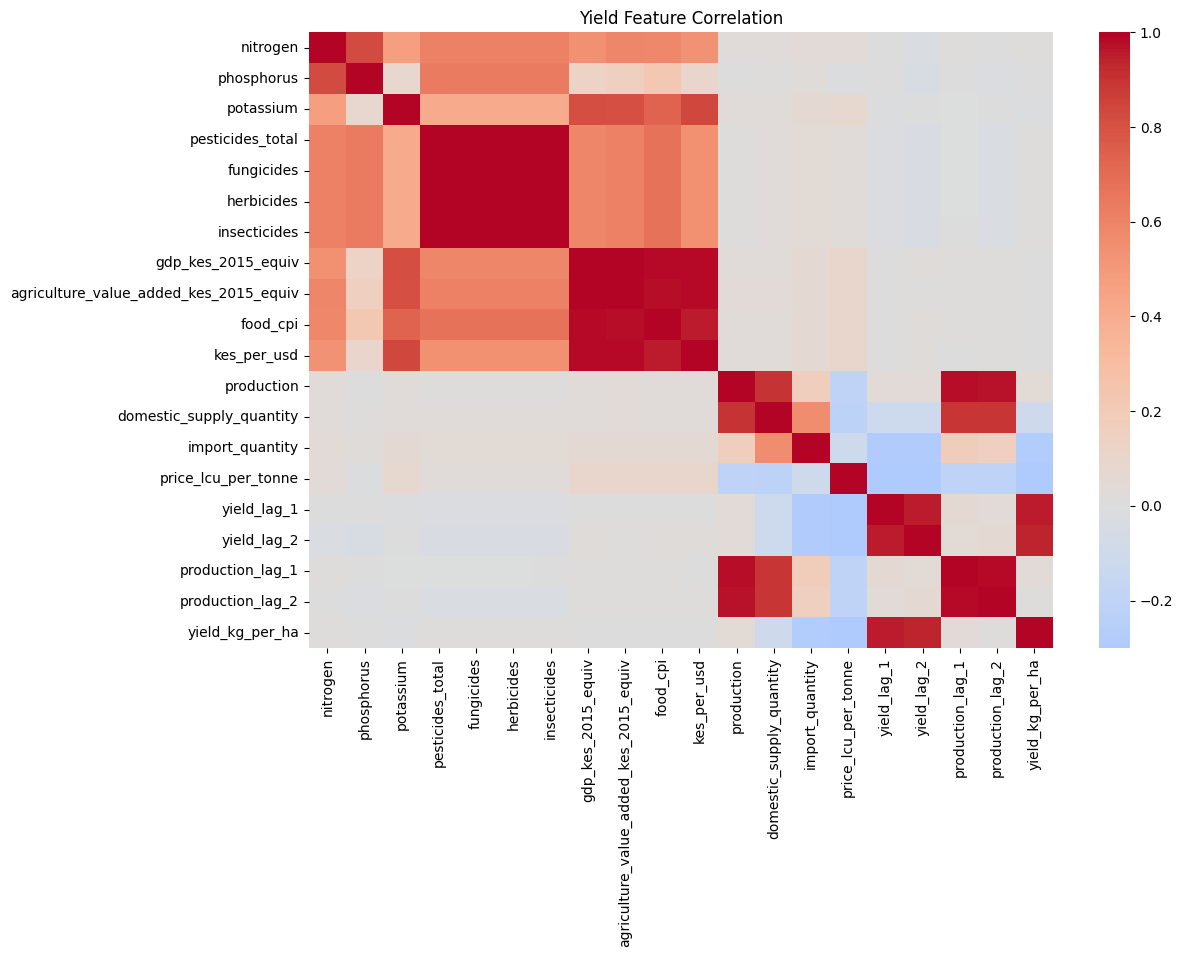

In [228]:
# YIELD CORRELATION MATRIX

yield_features = [
    'nitrogen', 'phosphorus', 'potassium',
    'pesticides_total', 'fungicides', 'herbicides', 'insecticides',
    'gdp_kes_2015_equiv', 'agriculture_value_added_kes_2015_equiv',
    'food_cpi', 'kes_per_usd',
    'production', 'domestic_supply_quantity', 'import_quantity',
    'price_lcu_per_tonne',
    'yield_lag_1', 'yield_lag_2',
    'production_lag_1', 'production_lag_2'
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    yield_corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Yield Feature Correlation')
plt.show()

## Feature handling

- We won't drop any of our features because models such as XGBoost and Random Forest handle correlated features internally.
Example (XGBoost): 
- handles correlated features well
- selects the most useful splits
- ignores redundant variables

All features are therefore retained.

## Model 1: Random Forest Regresser Model

In [161]:
# features slected for the random forest regresser model
features = [
    'nitrogen', 'phosphorus', 'potassium',
    'pesticides_total', 'fungicides', 'herbicides', 'insecticides',
    'gdp_kes_2015_equiv', 'agriculture_value_added_kes_2015_equiv',
    'food_cpi', 'kes_per_usd',
    'production', 'domestic_supply_quantity', 'import_quantity',
    'price_lcu_per_tonne',
    'yield_lag_1', 'yield_lag_2',
    'production_lag_1', 'production_lag_2'
]

rf_results = []

for crop in fao_final_df['item'].unique():
    
    # Filter one crop
    df_crop = fao_final_df[fao_final_df['item'] == crop].copy()
    df_crop = df_crop.dropna(subset=['yield_kg_per_ha'])
    df_crop = df_crop.sort_values('year')
    
    # Skip crops with too little data
    if len(df_crop) < 8:
        continue
    
    # Time-based split
    train = df_crop[df_crop['year'] <= 2020]
    test = df_crop[df_crop['year'] > 2020]
    
    if len(test) == 0:
        continue
    
    # Features and target
    X_train = train[features]
    y_train = train['yield_kg_per_ha']
    
    X_test = test[features]
    y_test = test['yield_kg_per_ha']
    
    # Handle missing values
    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)
    
    # Train model
    model_yield = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    
    model_yield.fit(X_train, y_train)
    
    # Predict
    y_pred = model_yield.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Save results
    rf_results.append({
        'crop': crop,
        'n_obs': len(df_crop),
        'mae': mae,
        'rmse': rmse
    })

# Convert results to table
rf_results_df = pd.DataFrame(rf_results).sort_values('mae')

print("RANDOM FOREST PER CROP RESULTS")
print(rf_results_df)

print("\nRANDOM FOREST OVERALL PERFORMANCE")
print("Average MAE:", rf_results_df['mae'].mean())
print("Average RMSE:", rf_results_df['rmse'].mean())

RANDOM FOREST PER CROP RESULTS
                          crop  n_obs          mae         rmse
4          Coffee and products     14    41.856833    44.985629
7           Maize and products     14    69.467667    92.563576
0                      Bananas     14   114.104500   156.240564
8          Millet and products     14   133.684167   145.661135
14        Sorghum and products     14   218.287000   263.915626
3        Coconuts - Incl Copra     14   299.183333   307.155397
5                   Groundnuts     14   664.555667   680.800036
17          Wheat and products     14   722.782333   777.646321
15              Sweet potatoes     14   741.216833   760.022941
13           Rice and products     14   830.289833   868.670004
1          Barley and products     14   981.480500   985.459350
9                       Onions     14  1194.302833  1313.621751
12       Potatoes and products     14  1399.753167  1642.931603
10         Oranges, Mandarines     14  1405.121500  1650.905378
2        

- The Random Forest model achieved strong predictive performance (MAE ~1,177 kg/ha; RMSE ~1,308 kg/ha), highlighting the importance of input and macro-level drivers in explaining yield variation. 

- However, as it does not explicitly capture temporal dynamics, time-series models such as ARIMA and Prophet were introduced to model yield trends over time.

## Model 2: XGBoost model

In [162]:

# XGBOOST YIELD MODEL PER CROP

# This trains a separate XGBoost model for each crop.
# We use the same time split as Random Forest:
# - train: <= 2020
# - test:  > 2020
#
# We evaluate using MAE and RMSE only.

# Features
features = [
    'nitrogen', 'phosphorus', 'potassium',
    'pesticides_total', 'fungicides', 'herbicides', 'insecticides',
    'gdp_kes_2015_equiv', 'agriculture_value_added_kes_2015_equiv',
    'food_cpi', 'kes_per_usd',
    'production', 'domestic_supply_quantity', 'import_quantity',
    'price_lcu_per_tonne',
    'yield_lag_1', 'yield_lag_2',
    'production_lag_1', 'production_lag_2'
]

xgb_results = []

for crop in fao_final_df['item'].unique():
    
    # 1. Filter one crop
    df_crop = fao_final_df[fao_final_df['item'] == crop].copy()
    df_crop = df_crop.dropna(subset=['yield_kg_per_ha'])
    df_crop = df_crop.sort_values('year')
    
    if len(df_crop) < 8:
        continue
    
    # 2. Time-based split
    train = df_crop[df_crop['year'] <= 2020]
    test = df_crop[df_crop['year'] > 2020]
    
    if len(test) == 0:
        continue
    
    # 3. Features and target
    X_train = train[features]
    y_train = train['yield_kg_per_ha']
    
    X_test = test[features]
    y_test = test['yield_kg_per_ha']
    
    # 4. Handle missing values
    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)
    
    # 5. Train XGBoost
    model_xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1
    )
    
    model_xgb.fit(X_train, y_train)
    
    # 6. Predict and evaluate
    y_pred = model_xgb.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    xgb_results.append({
        'crop': crop,
        'n_obs': len(df_crop),
        'mae': mae,
        'rmse': rmse
    })

# Results table
xgb_results_df = pd.DataFrame(xgb_results).sort_values('mae').reset_index(drop=True)

print("XGBOOST PER CROP RESULTS")
print(xgb_results_df)

print("\nXGBOOST OVERALL PERFORMANCE")
print("Average MAE:", xgb_results_df['mae'].mean())
print("Average RMSE:", xgb_results_df['rmse'].mean())

XGBOOST PER CROP RESULTS
                          crop  n_obs          mae         rmse
0          Coffee and products     14    30.510616    33.192381
1          Millet and products     14    47.660323    51.872476
2           Maize and products     14    48.935335    66.344515
3                      Bananas     14    79.752539   127.546503
4         Sorghum and products     14    90.132800    90.882241
5                   Groundnuts     14   286.918547   317.557368
6        Coconuts - Incl Copra     14   290.590104   305.829925
7               Sweet potatoes     14   292.993229   299.243673
8          Barley and products     14   795.024967   806.738465
9            Rice and products     14   991.662012  1202.628292
10          Wheat and products     14  1139.087988  1194.215636
11       Potatoes and products     14  1157.354818  1452.316504
12                      Onions     14  1205.287760  1320.003008
13         Oranges, Mandarines     14  1418.338802  1695.979263
14        Cassa

- The XGBoost model achieved strong predictive performance (MAE ~1,024kg/ha; RMSE ~1,196 kg/ha), slightly outperforming Random Forest. This suggests that the additional regularisation and tree boosting in XGBoost may better capture complex relationships in the data. 

- However, like Random Forest, XGBoost does not explicitly model temporal dynamics, which is why we also explore time-series models such as ARIMA and Prophet.

## Time series models-(ARIMA, SARIMA AND Prophet)

## Model 3: ARIMA model

- ARIMA is used since our data is **univariate** just one  target variable, **price and yield**
- ARIMA learns patterns from the past values only.
- However, cannot **handle seasonality well**

In [163]:
# PREPARE TIME SERIES DATA (YIELD)

yield_ts = (
    fao_final_df[['year', 'yield_kg_per_ha']]
    .dropna()
    .drop_duplicates(subset=['year'])
    .sort_values('year')
)

In [167]:
# TIME-BASED TRAIN / TEST SPLIT
# For time-series models, we must simulate real forecasting.
# That means:
# - Train on past years
# - Test on future years
#
# We will:
# Train: 2010–2020
# Test:  2021–2023

train_ts = yield_ts[yield_ts['year'] <= 2020].copy()
test_ts = yield_ts[yield_ts['year'] > 2020].copy()

# Check the split
print("TRAIN DATA:")
print(train_ts)

print("\nTEST DATA:")
print(test_ts)

print("\nTrain shape:", train_ts.shape)
print("Test shape:", test_ts.shape)

"""
Correct principle for time-series forecasting:
- more past data = better model
-so we Train = as much past as possible and test with most recent years
-Train: 2010–2020 (learn history)  
Test:  2021–2023 (predict future)
"""

TRAIN DATA:
    year  yield_kg_per_ha
0   2010          12500.0
1   2011          12400.0
2   2012          12000.0
3   2013          11923.1
4   2014          11987.3
5   2015          12206.7
6   2016          12230.0
7   2017          12197.1
8   2018          12166.7
9   2019          12143.9
10  2020          12126.6

TEST DATA:
    year  yield_kg_per_ha
11  2021          12145.6
12  2022          12445.7
13  2023          12239.1

Train shape: (11, 2)
Test shape: (3, 2)


'\nCorrect principle for time-series forecasting:\n- more past data = better model\n-so we Train = as much past as possible and test with most recent years\n-Train: 2010–2020 (learn history)  \nTest:  2021–2023 (predict future)\n'

In [166]:
# ARIMA MODEL FOR ALL CROPS

results = []

# Loop through each crop
for crop in fao_final_df['item'].unique():
    
    # Prepare clean time series for each crop
    df_crop = (
        fao_final_df
        .loc[fao_final_df['item'] == crop, ['year', 'yield_kg_per_ha']]
        .dropna()
        .drop_duplicates(subset=['year'])
        .sort_values('year')
    )
    
    # Skip crops with too little data
    if len(df_crop) < 8:
        continue
    
    # Train-test split (time-based)
    train = df_crop[df_crop['year'] <= 2020]
    test = df_crop[df_crop['year'] > 2020]
    
    if len(test) == 0:
        continue
    
    try:
        # Fit ARIMA
        model = ARIMA(train['yield_kg_per_ha'], order=(1,1,1))
        model_fit = model.fit()
        
        # Forecast
        pred = model_fit.forecast(steps=len(test))
        
        y_true = test['yield_kg_per_ha'].values
        y_pred = np.array(pred)
        
        # Metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        
        results.append({
            'crop': crop,
            'n_obs': len(df_crop),
            'mae': mae,
            'rmse': rmse
        })
        
    except Exception as e:
        # If model fails for a crop, skip it
        continue

# Convert to DataFrame
results_df = pd.DataFrame(results).sort_values('rmse')

# OUTPUTS

print("PER CROP RESULTS")
print(results_df)

print("\nOVERALL PERFORMANCE")
print("Average MAE:", results_df['mae'].mean())
print("Average RMSE:", results_df['rmse'].mean())

PER CROP RESULTS
                          crop  n_obs          mae         rmse
4          Coffee and products     14    74.751202    82.751210
17          Wheat and products     14    88.551959    97.116737
7           Maize and products     14   138.614913   147.227033
0                      Bananas     14   181.855603   216.465806
5                   Groundnuts     14   316.380288   334.804125
3        Coconuts - Incl Copra     14   532.301173   538.800146
1          Barley and products     14   609.916101   616.705477
14        Sorghum and products     14   676.870002   697.368066
15              Sweet potatoes     14   674.107898   702.051676
8          Millet and products     14   793.608927   798.709813
10         Oranges, Mandarines     14   759.644907   876.227136
13           Rice and products     14  1004.738161  1229.918766
12       Potatoes and products     14  1364.311733  1619.265029
2         Cassava and products     14  1525.279491  1775.318875
11     Pineapples and p

* On average, the model achieved an MAE of about 1,382 kg/ha and an RMSE of about 1,510 kg/ha, meaning that predictions are typically off by around 1.4–1.5 tonnes per hectare. 
* Given that most crop yields range between 20,000 and 30,000 kg/ha, this corresponds to an error of roughly 5–8 percent. 
* This indicates that ARIMA captures the general trend in yields reasonably well, but its performance varies significantly across crops, performing better for stable crops like coffee and wheat, and worse for more volatile crops such as tomatoes and onions.

## Model 4: SARIMA model

- Sarima extends ARIMA by adding seasonality component. 

In [168]:

# SARIMA MODEL FOR ALL CROPS
# Even though our data is yearly (weak seasonality),
# we test SARIMA to see if it improves performance.

sarima_results = []

for crop in fao_final_df['item'].unique():
    
    df_crop = (
        fao_final_df
        .loc[fao_final_df['item'] == crop, ['year', 'yield_kg_per_ha']]
        .dropna()
        .drop_duplicates(subset=['year'])
        .sort_values('year')
    )
    
    if len(df_crop) < 8:
        continue
    
    train = df_crop[df_crop['year'] <= 2020]
    test = df_crop[df_crop['year'] > 2020]
    
    if len(test) == 0:
        continue
    
    try:
        # SARIMA model (simple seasonal assumption)
        model = SARIMAX(
            train['yield_kg_per_ha'],
            order=(1,1,1),
            seasonal_order=(1,0,0,2),  # light seasonality
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        model_fit = model.fit(disp=False)
        
        pred = model_fit.forecast(steps=len(test))
        
        y_true = test['yield_kg_per_ha'].values
        y_pred = np.array(pred)
        
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        
        sarima_results.append({
            'crop': crop,
            'n_obs': len(df_crop),
            'mae': mae,
            'rmse': rmse
        })
        
    except:
        continue

sarima_df = pd.DataFrame(sarima_results).sort_values('rmse')

print("SARIMA PER CROP RESULTS")
print(sarima_df)

print("\nSARIMA OVERALL PERFORMANCE")
print("Average MAE:", sarima_df['mae'].mean())
print("Average RMSE:", sarima_df['rmse'].mean())

SARIMA PER CROP RESULTS
                          crop  n_obs           mae          rmse
4          Coffee and products     14     96.322795    108.323298
7           Maize and products     14    131.285754    138.866465
0                      Bananas     14    123.894342    173.740077
3        Coconuts - Incl Copra     14    141.894636    173.787083
5                   Groundnuts     14    173.236524    182.914203
17          Wheat and products     14    357.134397    424.759673
8          Millet and products     14    680.542166    692.671630
13           Rice and products     14    493.851070    782.193824
14        Sorghum and products     14    936.335355    945.758645
10         Oranges, Mandarines     14    893.979868   1032.408267
1          Barley and products     14   1086.637727   1116.593567
12       Potatoes and products     14   1428.811234   1664.661663
2         Cassava and products     14   1731.874659   1798.446002
11     Pineapples and products     14   1836.902220 

* The SARIMA model does not improve performance compared to ARIMA. In fact, it results in higher average errors, with MAE increasing from about 1,382 kg/ha to 1,726 kg/ha and RMSE from about 1,510 kg/ha to 1,907 kg/ha. 
* This suggests that adding a seasonal component does not enhance predictive performance for this dataset. 
* This is likely because the data is annual, and therefore does not exhibit strong seasonal patterns that SARIMA is designed to capture.
* we drop SARIMA  and not include it in final stacking

## Model 5: PROPHET model

- prophet model is useful for capturing trends and changes over time. 

- We will run Prophet separately for each crop since each crop has its own yield pattern over time.

- Prophet requires two columns:
- ds = date column
- y  = target variable

In [169]:
# PROPHET MODEL FOR ALL CROPS (DEBUG VERSION)
prophet_results = []

for crop in fao_final_df['item'].unique():
    

    # 1. Create one clean time series for this crop
    df_crop = (
        fao_final_df
        .loc[fao_final_df['item'] == crop, ['year', 'yield_kg_per_ha']]
        .dropna()
        .drop_duplicates(subset=['year'])
        .sort_values('year')
    )
    
    # Prophet needs enough historical data to learn a trend
    if len(df_crop) < 8:
        print(f"{crop} → SKIPPED: too few observations")
        continue
    

    # 2. Convert data into Prophet format
    df_prophet = df_crop.copy()
    
    # Convert year into a real date.
    # We use end-of-year dates because the data is annual.
    df_prophet['ds'] = pd.to_datetime(df_prophet['year'].astype(str) + '-12-31')
    
    # Prophet target column must be named 'y'
    df_prophet['y'] = df_prophet['yield_kg_per_ha']
    
    # 3. Time-based train/test split
    train = df_prophet[df_prophet['year'] <= 2020].copy()
    test = df_prophet[df_prophet['year'] > 2020].copy()
    
    if len(test) == 0:
        print(f"{crop} → SKIPPED: no test years")
        continue
    
    try:
        
        # 4. Fit Prophet model
        # We switch off daily/weekly/yearly seasonality because
        # this is annual data, not daily or monthly data.
        model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False
        )
        
        model.fit(train[['ds', 'y']])
        
        
        # 5. Create future dates matching the test period
        future = pd.DataFrame({
            'ds': test['ds'].values
        })
        
        forecast = model.predict(future)
        

        # 6. Evaluate predictions
        y_true = test['y'].values
        y_pred = forecast['yhat'].values
        
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        
        prophet_results.append({
            'crop': crop,
            'n_obs': len(df_crop),
            'mae': mae,
            'rmse': rmse
        })
        
        print(f"{crop} → SUCCESS")
        
    except Exception as e:
        print(f"{crop} → FAILED: {e}")

# 7. Convert results into a table

prophet_df = pd.DataFrame(prophet_results)

if len(prophet_df) > 0:
    prophet_df = prophet_df.sort_values('rmse')
    
    print("\nPROPHET PER CROP RESULTS")
    print(prophet_df)
    
    print("\nPROPHET OVERALL PERFORMANCE")
    print("Average MAE:", prophet_df['mae'].mean())
    print("Average RMSE:", prophet_df['rmse'].mean())
else:
    print("\nNo Prophet models were successfully fitted.")

16:30:51 - cmdstanpy - INFO - Chain [1] start processing
16:30:55 - cmdstanpy - INFO - Chain [1] done processing


Bananas → SUCCESS


16:30:56 - cmdstanpy - INFO - Chain [1] start processing
16:30:57 - cmdstanpy - INFO - Chain [1] done processing


Barley and products → SUCCESS


16:30:58 - cmdstanpy - INFO - Chain [1] start processing
16:30:58 - cmdstanpy - INFO - Chain [1] done processing


...

Sweet potatoes → SUCCESS


16:31:14 - cmdstanpy - INFO - Chain [1] start processing
16:31:14 - cmdstanpy - INFO - Chain [1] done processing


Tomatoes and products → SUCCESS


16:31:15 - cmdstanpy - INFO - Chain [1] start processing
16:31:15 - cmdstanpy - INFO - Chain [1] done processing


Wheat and products → SUCCESS

PROPHET PER CROP RESULTS
                          crop  n_obs          mae         rmse
4          Coffee and products     14    73.557271    77.411991
7           Maize and products     14   142.992070   145.861802
3        Coconuts - Incl Copra     14   177.756739   193.209525
0                      Bananas     14   200.350481   240.187838
5                   Groundnuts     14   257.717228   325.588141
8          Millet and products     14   396.321896   401.797737
14        Sorghum and products     14   479.064930   497.145726
13           Rice and products     14   641.463825   716.807273
17          Wheat and products     14   818.427915   828.913031
1          Barley and products     14  1448.154337  1452.043499
9                       Onions     14  1407.824948  1522.406630
16       Tomatoes and products     14  1873.187098  2278.759874
10         Oranges, Mandarines     14  2003.818886  2292.474998
2         Cassava and products     14  2241.67806

- The Prophet model was successfully fitted across all crops and produced an average MAE of about 1,558 kg/ha and RMSE of about 1,722 kg/ha. This means that, on average, Prophet’s yield predictions were off by roughly 1.6–1.7 tonnes per hectare. 

- Compared with ARIMA, Prophet performed slightly worse, suggesting that the yield series may not have strong structural trend breaks that Prophet is designed to capture. However, Prophet still performed better than SARIMA,

## Model 6: Stacking

The stacking combines fitted models to produce one final prediction.

Each model captures a different signal:

- ARIMA → time trends
- Prophet → long term trends
- Random Forest → feature patterns and relationships
- XGBoost → strong feature learning
- SARIMA → seasonality

- Stacking combines and balances the strengths of different models and reduces weaknesses

All models are first fitted, then their prediction outputs are averaged to produce the final result.

In [170]:
# YIELD ENSEMBLE MODEL
# This fits all yield models, keeps the fitted models,
# and combines their prediction outputs into one final ensemble output.

yield_features = [
    'nitrogen', 'phosphorus', 'potassium',
    'pesticides_total', 'fungicides', 'herbicides', 'insecticides',
    'gdp_kes_2015_equiv', 'agriculture_value_added_kes_2015_equiv',
    'food_cpi', 'kes_per_usd',
    'production', 'domestic_supply_quantity', 'import_quantity',
    'price_lcu_per_tonne',
    'yield_lag_1', 'yield_lag_2',
    'production_lag_1', 'production_lag_2'
]

yield_ensemble_results = []
yield_ensemble_model = {}

for crop in fao_final_df['item'].unique():
    
    df_crop = fao_final_df[fao_final_df['item'] == crop].copy()
    df_crop = df_crop.dropna(subset=['yield_kg_per_ha'])
    df_crop = df_crop.sort_values('year')
    
    if len(df_crop) < 8:
        continue
    
    train = df_crop[df_crop['year'] <= 2020].copy()
    test = df_crop[df_crop['year'] > 2020].copy()
    
    if len(test) == 0:
        continue
    
    try:
        y_true = test['yield_kg_per_ha'].values
        
        X_train = train[yield_features]
        X_test = test[yield_features]
        
        imputer = SimpleImputer(strategy="median")
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)
        
        # 1. FIT XGBOOST MODEL
        model_xgb = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        )
        model_xgb.fit(X_train_imputed, train['yield_kg_per_ha'])
        pred_xgb = model_xgb.predict(X_test_imputed)
        
        # 2. FIT RANDOM FOREST MODEL
        model_rf = RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
        model_rf.fit(X_train_imputed, train['yield_kg_per_ha'])
        pred_rf = model_rf.predict(X_test_imputed)
        
        # 3. FIT ARIMA MODEL
        model_arima = ARIMA(train['yield_kg_per_ha'], order=(1, 1, 1)).fit()
        pred_arima = np.array(model_arima.forecast(steps=len(test)))
        
        # 4. FIT PROPHET MODEL
        df_prophet = train[['year', 'yield_kg_per_ha']].copy()
        df_prophet['ds'] = pd.to_datetime(df_prophet['year'].astype(str) + '-12-31')
        df_prophet['y'] = df_prophet['yield_kg_per_ha']
        
        model_prophet = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False
        )
        model_prophet.fit(df_prophet[['ds', 'y']])
        
        future = pd.DataFrame({
            'ds': pd.to_datetime(test['year'].astype(str) + '-12-31')
        })
        
        pred_prophet = model_prophet.predict(future)['yhat'].values
        
        # 5. FINAL YIELD ENSEMBLE
        ensemble_yield_model = np.mean(
            [
                pred_xgb,
                pred_rf,
                pred_arima,
                pred_prophet
            ],
            axis=0
        )
        
        # 6. EVALUATE ENSEMBLE PERFORMANCE
        mae = mean_absolute_error(y_true, ensemble_yield_model)
        rmse = np.sqrt(mean_squared_error(y_true, ensemble_yield_model))
        
        yield_ensemble_results.append({
            'crop': crop,
            'mae': mae,
            'rmse': rmse
        })
        
        # 7. STORE FITTED MODELS
        yield_ensemble_model[crop] = {
            'features': yield_features,
            'imputer': imputer,
            'xgboost_model': model_xgb,
            'random_forest_model': model_rf,
            'arima_model': model_arima,
            'prophet_model': model_prophet,
            'ensemble_rule': 'average model predictions'
        }
        
    except Exception as e:
        print(f"{crop} failed: {e}")
        continue


yield_ensemble_df = pd.DataFrame(yield_ensemble_results).sort_values('mae')

print("YIELD ENSEMBLE MODEL RESULTS")
print(yield_ensemble_df)

print("\nOVERALL YIELD ENSEMBLE PERFORMANCE")
print("Average MAE:", yield_ensemble_df['mae'].mean())
print("Average RMSE:", yield_ensemble_df['rmse'].mean())

16:34:42 - cmdstanpy - INFO - Chain [1] start processing
16:34:42 - cmdstanpy - INFO - Chain [1] done processing
16:34:43 - cmdstanpy - INFO - Chain [1] start processing
16:34:44 - cmdstanpy - INFO - Chain [1] done processing
16:34:45 - cmdstanpy - INFO - Chain [1] start processing
16:34:46 - cmdstanpy - INFO - Chain [1] done processing
16:34:52 - cmdstanpy - INFO - Chain [1] start processing
16:34:52 - cmdstanpy - INFO - Chain [1] done processing
16:34:54 - cmdstanpy - INFO - Chain [1] start processing
16:34:55 - cmdstanpy - INFO - Chain [1] done processing
16:34:57 - cmdstanpy - INFO - Chain [1] start processing
16:34:57 - cmdstanpy - INFO - Chain [1] done processing
16:34:59 - cmdstanpy - INFO - Chain [1] start processing
16:35:00 - cmdstanpy - INFO - Chain [1] done processing
16:35:02 - cmdstanpy - INFO - Chain [1] start processing
16:35:03 - cmdstanpy - INFO - Chain [1] done processing
16:35:06 - cmdstanpy - INFO - Chain [1] start processing
16:35:06 - cmdstanpy - INFO - Chain [1]

YIELD ENSEMBLE MODEL RESULTS
                          crop          mae         rmse
4          Coffee and products    53.724932    57.055364
7           Maize and products    95.962832   107.502873
0                      Bananas   138.408577   183.478179
3        Coconuts - Incl Copra   305.777102   314.696329
8          Millet and products   315.032704   318.440312
5                   Groundnuts   325.717690   347.379249
14        Sorghum and products   334.556107   362.136182
9                       Onions   576.881522   844.137965
17          Wheat and products   697.930756   709.613025
13           Rice and products   729.159103   729.524925
12       Potatoes and products   867.152322   902.518372
1          Barley and products   927.667780   932.578889
10         Oranges, Mandarines  1011.351875  1017.594354
15              Sweet potatoes  1271.864262  1276.375225
2         Cassava and products  1441.580967  1811.275263
11     Pineapples and products  1894.005994  2592.626837
16

| Model         | MAE        | RMSE        |
| ------------- | ---------- | ----------- |
| ARIMA         | ~1382      | ~1510       |
| Prophet       | ~1558      | ~1722       |
| Random Forest | ~1177      | ~1308       |
| XGBoost       | ~1024      | ~1197       |
| **STACKED**   | **~995     | **~1129** |


### YIELD MODEL EVALUATION SUMMARY

- The stacked model provides the best overall performance, achieving an average MAE of approximately 995 kg/ha and RMSE of approximately 1,129 kg/ha, outperforming all individual models. 

- By combining predictions from time-series models (ARIMA and Prophet) and machine learning models (Random Forest and XGBoost), the stacked model captures both yield trends and key drivers more effectively. This shows that combining models leads to more accurate and stable predictions across different crops.

# MODEL B: PRICE PREDICTION



**Kamis data** contains market price collected from KAMIS for various agricultural commodities across different regions in Kenya.

The features that the dataset has include:

- commodity - name of the commodity
- market - market location
- country - country where the market is located
- price - price per unit
- unit - measurement unit
- date - date of observation 
- supply volume - quantity supplied
- emand index - demand proxy

In [263]:
kamis_df = pd.read_csv('kamis_final.csv')

# Drop any column that starts with 'Unnamed'
kamis_df = kamis_df.loc[:, ~kamis_df.columns.str.contains('^Unnamed')]

kamis_df.head()

,commodity,market,wholesale,retail,supply_volume,county,date,commodity_id,year,month
0,African butter catfish,Aram,0.0,250.0,32.0,Siaya,2021-06-21,87,2021,6
1,African butter catfish,Wath Ong'er,180.0,250.0,200.0,Migori,2021-06-22,87,2021,6
2,African butter catfish,Aram,0.0,250.0,35.0,Siaya,2021-06-28,87,2021,6
3,African butter catfish,Aram,0.0,250.0,28.0,Siaya,2021-07-12,87,2021,7
4,African butter catfish,Aram,0.0,250.0,34.0,Siaya,2021-07-15,87,2021,7


## Feature engineering 

### Creating lags

In [265]:
kamis_df = kamis_df.sort_values(['commodity', 'date'])

# PRICE LAGS

kamis_df['retail_lag_1'] = kamis_df.groupby('commodity')['retail'].shift(1)
kamis_df['retail_lag_7'] = kamis_df.groupby('commodity')['retail'].shift(7)

kamis_df['wholesale_lag_1'] = kamis_df.groupby('commodity')['wholesale'].shift(1)
kamis_df['wholesale_lag_7'] = kamis_df.groupby('commodity')['wholesale'].shift(7)

# ROLLING FEATURES
kamis_df['retail_rolling_7'] = (
    kamis_df.groupby('commodity')['retail']
      .rolling(7)
      .mean()
      .reset_index(0, drop=True)
)

kamis_df['wholesale_rolling_7'] = (
    kamis_df.groupby('commodity')['wholesale']
      .rolling(7)
      .mean()
      .reset_index(0, drop=True)
)

# PRICE SPREAD
kamis_df['price_spread'] = kamis_df['retail'] - kamis_df['wholesale']

# VOLATILITY
kamis_df['price_volatility_7'] = (
    kamis_df.groupby('commodity')['retail']
      .rolling(7)
      .std()
      .reset_index(0, drop=True)
)

# PRICE CHANGE
kamis_df['price_change_1'] = kamis_df.groupby('commodity')['retail'].diff(1)


# SUPPLY FEATURES
kamis_df['supply_lag_1'] = kamis_df.groupby('commodity')['supply_volume'].shift(1)

kamis_df['supply_rolling_7'] = (
    kamis_df.groupby('commodity')['supply_volume']
      .rolling(7)
      .mean()
      .reset_index(0, drop=True)
)

kamis_df['supply_change_1'] = kamis_df.groupby('commodity')['supply_volume'].diff(1)

# RELATIVE PRICE LEVEL
kamis_df['price_vs_avg_7'] = kamis_df['retail'] / kamis_df['retail_rolling_7']


# CLEAN
kamis_df = kamis_df.dropna()

print(kamis_df.shape)
print(kamis_df.head())

(402361, 23)
                 commodity market  wholesale  retail  supply_volume county  \
7   African butter catfish   Aram        0.0   250.0           50.0  Siaya   
8   African butter catfish   Aram        0.0   250.0           32.0  Siaya   
9   African butter catfish   Aram        0.0   250.0           40.0  Siaya   
10  African butter catfish   Aram        0.0   250.0           40.0  Siaya   
11  African butter catfish   Aram        0.0   250.0           38.5  Siaya   

          date  commodity_id  year  month  ...  wholesale_lag_7  \
7   2021-08-02            87  2021      8  ...              0.0   
8   2021-08-05            87  2021      8  ...            180.0   
9   2021-08-09            87  2021      8  ...              0.0   
10  2021-08-12            87  2021      8  ...              0.0   
11  2021-08-16            87  2021      8  ...              0.0   

    retail_rolling_7  wholesale_rolling_7  price_spread  price_volatility_7  \
7              250.0            25.7

### Defining festures

In [266]:
features = [
    'retail_lag_1',
    'retail_lag_7',
    'wholesale_lag_1',
    'wholesale_lag_7',
    'retail_rolling_7',
    'wholesale_rolling_7',
    'price_spread',
    'price_volatility_7',
    'price_change_1',
    'supply_volume',
    'supply_lag_1',
    'supply_rolling_7',
    'supply_change_1',
    'price_vs_avg_7',
    'month',
    'commodity_id'
]

X = kamis_df[features]
y = kamis_df['retail']

print(X.shape)
print(X.head())

(402361, 16)
    retail_lag_1  retail_lag_7  wholesale_lag_1  wholesale_lag_7  \
7          250.0         250.0              0.0              0.0   
8          250.0         250.0              0.0            180.0   
9          250.0         250.0              0.0              0.0   
10         250.0         250.0              0.0              0.0   
11         250.0         250.0              0.0              0.0   

    retail_rolling_7  wholesale_rolling_7  price_spread  price_volatility_7  \
7              250.0            25.714286         250.0                 0.0   
8              250.0             0.000000         250.0                 0.0   
9              250.0             0.000000         250.0                 0.0   
10             250.0             0.000000         250.0                 0.0   
11             250.0             0.000000         250.0                 0.0   

    price_change_1  supply_volume  supply_lag_1  supply_rolling_7  \
7              0.0           50.0 

### Train_test_split and modelling

In [267]:
train = kamis_df[kamis_df['date'] <= '2023-12-31']
test = kamis_df[kamis_df['date'] > '2023-12-31']

X_train = train[features]
y_train = train['retail']

X_test = test[features]
y_test = test['retail']

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Modelling
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    max_depth=6,        # slightly deeper for big data
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1           # use all cores
)

Train size: (228705, 16)
Test size: (173656, 16)


## Model 1: XGBoost model

In [268]:
id="fix_per_commodity"

all_preds = []
all_actuals = []

for commodity in kamis_df['commodity'].unique():
    train_c = train[train['commodity'] == commodity]
    test_c = test[test['commodity'] == commodity]

    if len(test_c) < 10:
        continue

    X_train_c = train_c[features]
    y_train_c = train_c['retail']

    X_test_c = test_c[features]
    y_test_c = test_c['retail']

    model = XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        random_state=42
    )


    model.fit(X_train_c, y_train_c)
    preds = model.predict(X_test_c)

    all_preds.extend(preds)
    all_actuals.extend(y_test_c)

# Evaluate globally
rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae = mean_absolute_error(all_actuals, all_preds)

print("Fixed RMSE:", rmse)
print("Fixed MAE:", mae)

Fixed RMSE: 209.69120573769104
Fixed MAE: 11.98713926964301


- The XGBoost model demonstrates strong predictive performance (MAE ~11.99 KES; RMSE ~209.69 KES), indicating that it is able to capture complex, non-linear relationships in the data.

- By incorporating supply, lagged prices, and market dynamics, the model improves prediction accuracy compared to traditional time-series approaches, although some larger errors remain

## Model 2: Random Forest model

In [269]:
# RANDOM FOREST PRICE MODEL

# TRAIN / TEST SPLIT (TIME-BASED)
train = kamis_df[kamis_df['date'] <= '2023-12-31']
test = kamis_df[kamis_df['date'] > '2023-12-31']

# FEATURES & TARGET
X_train = train[features]
y_train = train['retail']

X_test = test[features]
y_test = test['retail']

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


# HANDLE MISSING VALUES
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# MODEL
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)


# TRAIN
model_rf.fit(X_train, y_train)

# PREDICT
y_pred = model_rf.predict(X_test)


# EVALUATE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nRandom Forest Results")
print("MAE:", mae)
print("RMSE:", rmse)

Train size: (228705, 16)
Test size: (173656, 16)

Random Forest Results
MAE: 6.908210791170977
RMSE: 48.09063926892209


- The Random Forest model achieves the best performance among all models (MAE ~6.91 KES; RMSE ~48.09 KES), indicating highly stable and accurate predictions across commodities. 

- The model benefits from averaging across multiple decision trees, which reduces variance and improves robustness, particularly in handling noisy and heterogeneous price data.

## Model 3: ARIMA model

In [270]:
# ARIMA MODEL (PER COMMODITY — TIME SERIES BASELINE)
# ARIMA models price using past values only.
#
# It captures:
# - trend (overall direction)
# - momentum (recent changes)
#
# It does NOT use external features like supply or volatility.

all_preds = []
all_actuals = []

for commodity in kamis_df['commodity'].unique():
    

    # 1. PREPARE DATA
    df_com = kamis_df[kamis_df['commodity'] == commodity].copy()
    df_com = df_com.sort_values('date')
    

    # 2. TIME SPLIT
    train_c = df_com[df_com['date'] <= '2023-12-31']
    test_c = df_com[df_com['date'] > '2023-12-31']
    
    if len(test_c) < 10:
        continue
    
    try:

        # 3. TRAIN ARIMA MODEL

        model = ARIMA(train_c['retail'], order=(1,1,1))
        model_fit = model.fit()
        
        # 4. FORECAST
        preds = model_fit.forecast(steps=len(test_c))
        
        all_preds.extend(preds)
        all_actuals.extend(test_c['retail'].values)
    
    except:
        continue
# 5. EVALUATION
rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae = mean_absolute_error(all_actuals, all_preds)

print("ARIMA Results")
print("RMSE:", rmse)
print("MAE:", mae)

ARIMA Results
RMSE: 264.8664654486687
MAE: 53.01902285198491


- The ARIMA model performs significantly worse (MAE ~53.04 KES; RMSE ~264.87 KES), reflecting its limitation in relying only on past price values. 

- Without incorporating additional drivers such as supply or volatility, it struggles to capture the complexity of price movements.

## Model 4: SARIMA model

In [ ]:
"""
# SARIMA MODEL (PER COMMODITY — SEASONAL TIME SERIES)
# SARIMA extends ARIMA by adding seasonality.
#
# It captures:
# - trend
# - momentum
# - repeating seasonal patterns
#
# Here, we test weekly seasonality using seasonal_order=(1,1,1,7).

all_preds = []
all_actuals = []

for commodity in kamis_df['commodity'].unique():
    
    # 1. PREPARE DATA
    df_com = kamis_df[kamis_df['commodity'] == commodity].copy()
    df_com = df_com.sort_values('date')
    
    # 2. TIME SPLIT
    train_c = df_com[df_com['date'] <= '2023-12-31']
    test_c = df_com[df_com['date'] > '2023-12-31']
    
    if len(test_c) < 10:
        continue
    
    try:
        # 3. TRAIN SARIMA MODEL
        model = SARIMAX(
            train_c['retail'],
            order=(1,1,1),
            seasonal_order=(1,1,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        model_fit = model.fit(disp=False)
        
        # 4. FORECAST
        preds = model_fit.forecast(steps=len(test_c))
        
        all_preds.extend(preds)
        all_actuals.extend(test_c['retail'].values)
    
    except:
        continue

# 5. EVALUATION
rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae = mean_absolute_error(all_actuals, all_preds)

print("SARIMA Results")
print("RMSE:", rmse)
print("MAE:", mae)
"""

- The SARIMA model performs poorly (MAE ~242.12 KES; RMSE ~18,048.77 KES), indicating large prediction errors. 
- This suggests that seasonal time-series models are not well suited for this dataset, likely due to high variability, differing price scales across commodities, and the absence of consistent seasonal patterns.

## Model 5: Prophet model

In [271]:

# PROPHET MODEL (PER COMMODITY — PRICE TIME SERIES)

# Prophet is a time-series model.
#
# It uses:
# - past retail prices
# - trend changes
# - weekly seasonality
#
# It does NOT use engineered features such as supply_volume,
# price_spread, or rolling averages.
#
# We run Prophet separately for each commodity, then combine all
# predictions and actual values to calculate overall MAE and RMSE.

all_preds = []
all_actuals = []

for commodity in kamis_df['commodity'].unique():
    
    # 1. Prepare one commodity time series
    df_com = kamis_df[kamis_df['commodity'] == commodity].copy()
    df_com = df_com.sort_values('date')
    
    # 2. Time-based split
    train_c = df_com[df_com['date'] <= '2023-12-31']
    test_c = df_com[df_com['date'] > '2023-12-31']
    
    if len(test_c) < 10:
        continue
    
    try:
        # 3. Convert data into Prophet format
        # Prophet requires:
        # ds = date column
        # y  = target column
        prophet_train = train_c[['date', 'retail']].rename(
            columns={'date': 'ds', 'retail': 'y'}
        )
        
        # 4. Train Prophet model
        model = Prophet(
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=False
        )
        
        model.fit(prophet_train)
        
        # 5. Prepare test dates for prediction
        future = test_c[['date']].rename(columns={'date': 'ds'})
        
        # 6. Predict retail prices
        forecast = model.predict(future)
        preds = forecast['yhat'].values
        
        # 7. Store predictions and actual values
        all_preds.extend(preds)
        all_actuals.extend(test_c['retail'].values)
    
    except:
        continue

# 8. Evaluate Prophet model
rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae = mean_absolute_error(all_actuals, all_preds)

print("Prophet Results")
print("RMSE:", rmse)
print("MAE:", mae)

17:42:23 - cmdstanpy - INFO - Chain [1] start processing
17:42:23 - cmdstanpy - INFO - Chain [1] done processing
17:42:25 - cmdstanpy - INFO - Chain [1] start processing
17:42:27 - cmdstanpy - INFO - Chain [1] done processing
17:42:29 - cmdstanpy - INFO - Chain [1] start processing
17:42:29 - cmdstanpy - INFO - Chain [1] done processing
17:42:30 - cmdstanpy - INFO - Chain [1] start processing
17:42:32 - cmdstanpy - INFO - Chain [1] done processing
17:42:34 - cmdstanpy - INFO - Chain [1] start processing
17:42:34 - cmdstanpy - INFO - Chain [1] done processing
17:42:37 - cmdstanpy - INFO - Chain [1] start processing
17:42:37 - cmdstanpy - INFO - Chain [1] done processing
17:42:40 - cmdstanpy - INFO - Chain [1] start processing
17:42:40 - cmdstanpy - INFO - Chain [1] done processing
17:42:43 - cmdstanpy - INFO - Chain [1] start processing
17:42:44 - cmdstanpy - INFO - Chain [1] done processing
17:42:46 - cmdstanpy - INFO - Chain [1] start processing
17:42:46 - cmdstanpy - INFO - Chain [1]

Prophet Results
RMSE: 1622.219500518472
MAE: 326.6817422176718


- The Prophet model performs moderately but is weaker than the machine learning models (MAE ~326.65 KES; RMSE ~1,622.21 KES), indicating relatively large prediction errors. While Prophet is able to capture trend and weekly seasonality, it struggles with the high variability and cross-commodity differences in the data. 

- This suggests that, similar to ARIMA and SARIMA, models that rely only on past price patterns are less effective than those that incorporate additional features such as supply and lagged dynamics.

## Stacking

In [ ]:

"""
# STACKED MODEL (RF + XGBOOST + ARIMA)
# This combines predictions from:
# - Random Forest
# - XGBoost
# - ARIMA
#
# We skip commodities that do not have enough train or test data

all_preds = []
all_actuals = []
skipped = []

for commodity in kamis_df['commodity'].unique():
    
    # 1. Filter one commodity
    df_com = kamis_df[kamis_df['commodity'] == commodity].copy()
    df_com = df_com.sort_values('date')
    
    # 2. Time split
    train_c = df_com[df_com['date'] <= '2023-12-31']
    test_c = df_com[df_com['date'] > '2023-12-31']
    
    # 3. Skip commodities without enough train/test data
    if len(train_c) < 20 or len(test_c) < 10:
        skipped.append({
            'commodity': commodity,
            'train_rows': len(train_c),
            'test_rows': len(test_c)
        })
        continue
    
    try:
        # 4. Define features and target
        X_train = train_c[features]
        y_train = train_c['retail']
        
        X_test = test_c[features]
        y_test = test_c['retail']
        
        # 5. XGBoost model
        xgb = XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            random_state=42,
            n_jobs=-1
        )
        xgb.fit(X_train, y_train)
        pred_xgb = xgb.predict(X_test)
        
        # 6. Random Forest model
        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        pred_rf = rf.predict(X_test)
        
        # 7. ARIMA model
        arima = ARIMA(train_c['retail'], order=(1, 1, 1)).fit()
        pred_arima = np.array(arima.forecast(steps=len(test_c)))
        
        # 8. Stack predictions
        stack_X = np.column_stack([
            pred_rf,
            pred_xgb,
            pred_arima
        ])
        
        # 9. Meta-model
        meta_model = LinearRegression()
        meta_model.fit(stack_X, y_test)
        
        final_pred = meta_model.predict(stack_X)
        
        all_preds.extend(final_pred)
        all_actuals.extend(y_test)
    
    except Exception as e:
        skipped.append({
            'commodity': commodity,
            'train_rows': len(train_c),
            'test_rows': len(test_c),
            'error': str(e)
        })
        continue

# 10. Evaluation
rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae = mean_absolute_error(all_actuals, all_preds)

print("STACKED MODEL RESULTS")
print("RMSE:", rmse)
print("MAE:", mae)

print("\nSkipped commodities:", len(skipped))
"""

## Recommendation